In [1]:
# ===============================
#  OPEN-SET MALWARE DETECTION
#  MalImg Dataset (Kaggle Ready)
# ===============================

import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import numpy as np

# ===============================
# CONFIG
# ===============================

DATA_ROOT = "/kaggle/input/cyberresearch/malimg_dataset"
TRAIN_PATH = os.path.join(DATA_ROOT, "train")
TEST_PATH  = os.path.join(DATA_ROOT, "test")

BATCH_SIZE = 64
EPOCHS_SSL = 5
EPOCHS_PROTO = 5
TEMPERATURE = 0.5
OPENSET_THRESHOLD = 0.7
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===============================
# TRANSFORMS
# ===============================

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

# ===============================
# LOAD DATASETS
# ===============================

train_dataset_full = datasets.ImageFolder(TRAIN_PATH, transform=transform)
test_dataset_full  = datasets.ImageFolder(TEST_PATH, transform=transform)

classes = train_dataset_full.classes
num_total_classes = len(classes)

print("Total families:", num_total_classes)

# ===============================
# OPEN-SET SPLIT (20 train / 5 unseen)
# ===============================

random.seed(SEED)

all_class_ids = list(range(num_total_classes))
random.shuffle(all_class_ids)

train_class_ids = all_class_ids[:20]
unseen_class_ids = all_class_ids[20:]

print("\nTrain families:")
print([classes[i] for i in train_class_ids])

print("\nUnseen families:")
print([classes[i] for i in unseen_class_ids])

# ===============================
# FILTER TRAIN DATA (20 families)
# ===============================

train_indices = [
    idx for idx, (_, label) in enumerate(train_dataset_full.samples)
    if label in train_class_ids
]

train_dataset = Subset(train_dataset_full, train_indices)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# ===============================
# FILTER UNSEEN TEST DATA (5 families)
# ===============================

unseen_indices = [
    idx for idx, (_, label) in enumerate(test_dataset_full.samples)
    if label in unseen_class_ids
]

unseen_dataset = Subset(test_dataset_full, unseen_indices)
unseen_loader = DataLoader(unseen_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ===============================
# ENCODER
# ===============================

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        self.backbone.fc = nn.Identity()

    def forward(self, x):
        return self.backbone(x)

# ===============================
# SIMCLR MODEL
# ===============================

class SimCLR(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return F.normalize(z, dim=1)

def nt_xent_loss(z1, z2, temperature=TEMPERATURE):
    batch = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2)
    sim = sim / temperature

    mask = torch.eye(batch*2, dtype=torch.bool).to(device)
    sim = sim.masked_fill(mask, -9e15)

    positives = torch.cat([
        torch.diag(sim, batch),
        torch.diag(sim, -batch)
    ], dim=0)

    denom = torch.logsumexp(sim, dim=1)
    loss = -positives + denom
    return loss.mean()

# ===============================
# SELF-SUPERVISED PRETRAINING
# ===============================

encoder = Encoder().to(device)
simclr = SimCLR(encoder).to(device)

optimizer = optim.Adam(simclr.parameters(), lr=1e-3)

print("\nStarting Self-Supervised Training...")

for epoch in range(EPOCHS_SSL):
    simclr.train()
    total_loss = 0

    for imgs, _ in tqdm(train_loader):
        imgs = imgs.to(device)

        x1 = imgs
        x2 = imgs.flip(-1)

        z1 = simclr(x1)
        z2 = simclr(x2)

        loss = nt_xent_loss(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"SSL Epoch {epoch+1}: {total_loss/len(train_loader):.4f}")

# ===============================
# PROTOTYPE CLASSIFIER
# ===============================

class PrototypeClassifier(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.prototypes = nn.Parameter(torch.randn(num_classes, 512))

    def forward(self, x):
        features = self.encoder(x)
        distances = torch.cdist(features, self.prototypes)
        return -distances

proto_model = PrototypeClassifier(encoder, 20).to(device)
optimizer = optim.Adam(proto_model.parameters(), lr=1e-4)

print("\nTraining Prototype Classifier...")

for epoch in range(EPOCHS_PROTO):
    proto_model.train()
    total_loss = 0

    for imgs, labels in tqdm(train_loader):
        imgs = imgs.to(device)

        # Remap labels to 0-19
        new_labels = torch.tensor(
            [train_class_ids.index(l) for l in labels]
        ).to(device)

        outputs = proto_model(imgs)
        loss = F.cross_entropy(outputs, new_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Prototype Epoch {epoch+1}: {total_loss/len(train_loader):.4f}")

# ===============================
# CLOSED-SET EVALUATION
# ===============================

print("\nClosed-set Evaluation (20 families):")

proto_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        new_labels = torch.tensor(
            [train_class_ids.index(l) for l in labels]
        ).to(device)

        outputs = proto_model(imgs)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(new_labels.cpu().numpy())

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("F1 Score:", f1_score(all_labels, all_preds, average="macro"))

# ===============================
# OPEN-SET EVALUATION
# ===============================

print("\nOpen-set Evaluation (5 unseen families):")

unknown_detected = 0
total = 0

with torch.no_grad():
    for imgs, _ in unseen_loader:
        imgs = imgs.to(device)

        outputs = proto_model(imgs)
        probs = F.softmax(outputs, dim=1)
        conf, _ = torch.max(probs, dim=1)

        unknown_detected += torch.sum(conf < OPENSET_THRESHOLD).item()
        total += imgs.size(0)

print("Unknown Detection Rate:",
      unknown_detected / total)


Device: cuda
Total families: 25

Train families:
['Malex.gen!J', 'Lolyda.AA1', 'Dontovo.A', 'Skintrim.N', 'Rbot!gen', 'C2LOP.P', 'Autorun.K', 'Fakerean', 'Lolyda.AT', 'Swizzor.gen!I', 'Instantaccess', 'Obfuscator.AD', 'Agent.FYI', 'Lolyda.AA3', 'VB.AT', 'Lolyda.AA2', 'Allaple.A', 'Wintrim.BX', 'Alueron.gen!J', 'Yuner.A']

Unseen families:
['C2LOP.gen!g', 'Dialplatform.B', 'Adialer.C', 'Allaple.L', 'Swizzor.gen!E']

Starting Self-Supervised Training...


100%|██████████| 89/89 [01:06<00:00,  1.33it/s]


SSL Epoch 1: 3.2353


100%|██████████| 89/89 [00:51<00:00,  1.74it/s]


SSL Epoch 2: 3.0906


...

Prototype Epoch 3: 0.1142


100%|██████████| 89/89 [00:37<00:00,  2.40it/s]


Prototype Epoch 4: 0.0937


100%|██████████| 89/89 [00:37<00:00,  2.39it/s]


Prototype Epoch 5: 0.0826

Closed-set Evaluation (20 families):
Accuracy: 0.9788992438895727
F1 Score: 0.9312503235029048

Open-set Evaluation (5 unseen families):
Unknown Detection Rate: 0.061946902654867256


In [2]:
# ===============================
# UPDATED CODE FOR IMPROVEMENTS
# ===============================

import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import numpy as np

# ===============================
# CONFIG
# ===============================

DATA_ROOT = "/kaggle/input/cyberresearch/malimg_dataset"
TRAIN_PATH = os.path.join(DATA_ROOT, "train")
TEST_PATH  = os.path.join(DATA_ROOT, "test")

BATCH_SIZE = 64
EPOCHS_SSL = 5
EPOCHS_PROTO = 5
TEMPERATURE = 0.5
OPENSET_THRESHOLD = 0.5  # Lowered threshold for open-set detection
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===============================
# TRANSFORMS (Including Augmentations)
# ===============================

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.ToTensor()
])

# ===============================
# LOAD DATASETS
# ===============================

train_dataset_full = datasets.ImageFolder(TRAIN_PATH, transform=transform)
test_dataset_full  = datasets.ImageFolder(TEST_PATH, transform=transform)

classes = train_dataset_full.classes
num_total_classes = len(classes)

print("Total families:", num_total_classes)

# ===============================
# OPEN-SET SPLIT (20 train / 5 unseen)
# ===============================

random.seed(SEED)

all_class_ids = list(range(num_total_classes))
random.shuffle(all_class_ids)

train_class_ids = all_class_ids[:20]
unseen_class_ids = all_class_ids[20:]

print("\nTrain families:")
print([classes[i] for i in train_class_ids])

print("\nUnseen families:")
print([classes[i] for i in unseen_class_ids])

# ===============================
# FILTER TRAIN DATA (20 families)
# ===============================

train_indices = [
    idx for idx, (_, label) in enumerate(train_dataset_full.samples)
    if label in train_class_ids
]

train_dataset = Subset(train_dataset_full, train_indices)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# ===============================
# FILTER UNSEEN TEST DATA (5 families)
# ===============================

unseen_indices = [
    idx for idx, (_, label) in enumerate(test_dataset_full.samples)
    if label in unseen_class_ids
]

unseen_dataset = Subset(test_dataset_full, unseen_indices)
unseen_loader = DataLoader(unseen_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ===============================
# ENCODER
# ===============================

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        self.backbone.fc = nn.Identity()

    def forward(self, x):
        return self.backbone(x)

# ===============================
# SIMCLR MODEL
# ===============================

class SimCLR(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return F.normalize(z, dim=1)

def nt_xent_loss(z1, z2, temperature=TEMPERATURE):
    batch = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2)
    sim = sim / temperature

    mask = torch.eye(batch*2, dtype=torch.bool).to(device)
    sim = sim.masked_fill(mask, -9e15)

    positives = torch.cat([
        torch.diag(sim, batch),
        torch.diag(sim, -batch)
    ], dim=0)

    denom = torch.logsumexp(sim, dim=1)
    loss = -positives + denom
    return loss.mean()

# ===============================
# SELF-SUPERVISED PRETRAINING
# ===============================

encoder = Encoder().to(device)
simclr = SimCLR(encoder).to(device)

optimizer = optim.Adam(simclr.parameters(), lr=1e-3)

print("\nStarting Self-Supervised Training...")

for epoch in range(EPOCHS_SSL):
    simclr.train()
    total_loss = 0

    for imgs, _ in tqdm(train_loader):
        imgs = imgs.to(device)

        x1 = imgs
        x2 = imgs.flip(-1)

        z1 = simclr(x1)
        z2 = simclr(x2)

        loss = nt_xent_loss(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"SSL Epoch {epoch+1}: {total_loss/len(train_loader):.4f}")

# ===============================
# PROTOTYPE CLASSIFIER (Using Cosine Similarity)
# ===============================

class PrototypeClassifier(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.prototypes = nn.Parameter(torch.randn(num_classes, 512))

    def forward(self, x):
        features = self.encoder(x)
        cos_sim = F.cosine_similarity(features.unsqueeze(1), self.prototypes.unsqueeze(0), dim=2)
        return cos_sim

proto_model = PrototypeClassifier(encoder, 20).to(device)
optimizer = optim.Adam(proto_model.parameters(), lr=1e-4)

print("\nTraining Prototype Classifier...")

for epoch in range(EPOCHS_PROTO):
    proto_model.train()
    total_loss = 0

    for imgs, labels in tqdm(train_loader):
        imgs = imgs.to(device)

        # Remap labels to 0-19
        new_labels = torch.tensor(
            [train_class_ids.index(l) for l in labels]
        ).to(device)

        outputs = proto_model(imgs)
        loss = F.cross_entropy(outputs, new_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Prototype Epoch {epoch+1}: {total_loss/len(train_loader):.4f}")

# ===============================
# CLOSED-SET EVALUATION
# ===============================

print("\nClosed-set Evaluation (20 families):")

proto_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        new_labels = torch.tensor(
            [train_class_ids.index(l) for l in labels]
        ).to(device)

        outputs = proto_model(imgs)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(new_labels.cpu().numpy())

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("F1 Score:", f1_score(all_labels, all_preds, average="macro"))

# ===============================
# OPEN-SET EVALUATION (With New Threshold)
# ===============================

print("\nOpen-set Evaluation (5 unseen families):")

unknown_detected = 0
total = 0

with torch.no_grad():
    for imgs, _ in unseen_loader:
        imgs = imgs.to(device)

        outputs = proto_model(imgs)
        conf, _ = torch.max(outputs, dim=1)

        unknown_detected += torch.sum(conf < OPENSET_THRESHOLD).item()
        total += imgs.size(0)

print("Unknown Detection Rate:",
      unknown_detected / total)


Device: cuda
Total families: 25

Train families:
['Malex.gen!J', 'Lolyda.AA1', 'Dontovo.A', 'Skintrim.N', 'Rbot!gen', 'C2LOP.P', 'Autorun.K', 'Fakerean', 'Lolyda.AT', 'Swizzor.gen!I', 'Instantaccess', 'Obfuscator.AD', 'Agent.FYI', 'Lolyda.AA3', 'VB.AT', 'Lolyda.AA2', 'Allaple.A', 'Wintrim.BX', 'Alueron.gen!J', 'Yuner.A']

Unseen families:
['C2LOP.gen!g', 'Dialplatform.B', 'Adialer.C', 'Allaple.L', 'Swizzor.gen!E']

Starting Self-Supervised Training...


100%|██████████| 89/89 [00:58<00:00,  1.51it/s]


SSL Epoch 1: 3.1149


100%|██████████| 89/89 [00:59<00:00,  1.50it/s]


SSL Epoch 2: 2.9912


...

Prototype Epoch 3: 2.4977


100%|██████████| 89/89 [00:43<00:00,  2.07it/s]


Prototype Epoch 4: 2.4347


100%|██████████| 89/89 [00:42<00:00,  2.08it/s]


Prototype Epoch 5: 2.3948

Closed-set Evaluation (20 families):
Accuracy: 0.9122560225074732
F1 Score: 0.7334294061641683

Open-set Evaluation (5 unseen families):
Unknown Detection Rate: 0.2831858407079646


In [3]:
# ===============================
# UPDATED CODE FOR THRESHOLD AND AUGMENTATION REFINEMENTS
# ===============================

import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import numpy as np

# ===============================
# CONFIG
# ===============================

DATA_ROOT = "/kaggle/input/cyberresearch/malimg_dataset"
TRAIN_PATH = os.path.join(DATA_ROOT, "train")
TEST_PATH  = os.path.join(DATA_ROOT, "test")

BATCH_SIZE = 64
EPOCHS_SSL = 5
EPOCHS_PROTO = 5
TEMPERATURE = 0.5
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===============================
# TRANSFORMS (Refined Augmentations)
# ===============================

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),  # Reduced augmentations
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),  # Slight jitter
    transforms.ToTensor()
])

# ===============================
# LOAD DATASETS
# ===============================

train_dataset_full = datasets.ImageFolder(TRAIN_PATH, transform=transform)
test_dataset_full  = datasets.ImageFolder(TEST_PATH, transform=transform)

classes = train_dataset_full.classes
num_total_classes = len(classes)

print("Total families:", num_total_classes)

# ===============================
# OPEN-SET SPLIT (20 train / 5 unseen)
# ===============================

random.seed(SEED)

all_class_ids = list(range(num_total_classes))
random.shuffle(all_class_ids)

train_class_ids = all_class_ids[:20]
unseen_class_ids = all_class_ids[20:]

print("\nTrain families:")
print([classes[i] for i in train_class_ids])

print("\nUnseen families:")
print([classes[i] for i in unseen_class_ids])

# ===============================
# FILTER TRAIN DATA (20 families)
# ===============================

train_indices = [
    idx for idx, (_, label) in enumerate(train_dataset_full.samples)
    if label in train_class_ids
]

train_dataset = Subset(train_dataset_full, train_indices)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# ===============================
# FILTER UNSEEN TEST DATA (5 families)
# ===============================

unseen_indices = [
    idx for idx, (_, label) in enumerate(test_dataset_full.samples)
    if label in unseen_class_ids
]

unseen_dataset = Subset(test_dataset_full, unseen_indices)
unseen_loader = DataLoader(unseen_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ===============================
# ENCODER
# ===============================

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        self.backbone.fc = nn.Identity()

    def forward(self, x):
        return self.backbone(x)

# ===============================
# SIMCLR MODEL
# ===============================

class SimCLR(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return F.normalize(z, dim=1)

def nt_xent_loss(z1, z2, temperature=TEMPERATURE):
    batch = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2)
    sim = sim / temperature

    mask = torch.eye(batch*2, dtype=torch.bool).to(device)
    sim = sim.masked_fill(mask, -9e15)

    positives = torch.cat([
        torch.diag(sim, batch),
        torch.diag(sim, -batch)
    ], dim=0)

    denom = torch.logsumexp(sim, dim=1)
    loss = -positives + denom
    return loss.mean()

# ===============================
# SELF-SUPERVISED PRETRAINING
# ===============================

encoder = Encoder().to(device)
simclr = SimCLR(encoder).to(device)

optimizer = optim.Adam(simclr.parameters(), lr=1e-3)

print("\nStarting Self-Supervised Training...")

for epoch in range(EPOCHS_SSL):
    simclr.train()
    total_loss = 0

    for imgs, _ in tqdm(train_loader):
        imgs = imgs.to(device)

        x1 = imgs
        x2 = imgs.flip(-1)

        z1 = simclr(x1)
        z2 = simclr(x2)

        loss = nt_xent_loss(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"SSL Epoch {epoch+1}: {total_loss/len(train_loader):.4f}")

# ===============================
# PROTOTYPE CLASSIFIER (Using Cosine Similarity)
# ===============================

class PrototypeClassifier(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.prototypes = nn.Parameter(torch.randn(num_classes, 512))

    def forward(self, x):
        features = self.encoder(x)
        cos_sim = F.cosine_similarity(features.unsqueeze(1), self.prototypes.unsqueeze(0), dim=2)
        return cos_sim

proto_model = PrototypeClassifier(encoder, 20).to(device)
optimizer = optim.Adam(proto_model.parameters(), lr=1e-4)

print("\nTraining Prototype Classifier...")

for epoch in range(EPOCHS_PROTO):
    proto_model.train()
    total_loss = 0

    for imgs, labels in tqdm(train_loader):
        imgs = imgs.to(device)

        # Remap labels to 0-19
        new_labels = torch.tensor(
            [train_class_ids.index(l) for l in labels]
        ).to(device)

        outputs = proto_model(imgs)
        loss = F.cross_entropy(outputs, new_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Prototype Epoch {epoch+1}: {total_loss/len(train_loader):.4f}")

# ===============================
# CLOSED-SET EVALUATION
# ===============================

print("\nClosed-set Evaluation (20 families):")

proto_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        new_labels = torch.tensor(
            [train_class_ids.index(l) for l in labels]
        ).to(device)

        outputs = proto_model(imgs)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(new_labels.cpu().numpy())

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("F1 Score:", f1_score(all_labels, all_preds, average="macro"))

# ===============================
# OPEN-SET EVALUATION (Dynamic Threshold)
# ===============================

print("\nOpen-set Evaluation (5 unseen families):")

unknown_detected = 0
total = 0

# Dynamic Threshold: Use confidence distribution from training
train_confidences = []
with torch.no_grad():
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        outputs = proto_model(imgs)
        conf, _ = torch.max(outputs, dim=1)
        train_confidences.extend(conf.cpu().numpy())

# Set threshold as the 90th percentile of training confidence scores
threshold = np.percentile(train_confidences, 90)

print(f"Dynamic Threshold: {threshold:.4f}")

# Now, evaluate open-set detection with dynamic threshold
with torch.no_grad():
    for imgs, _ in unseen_loader:
        imgs = imgs.to(device)
        outputs = proto_model(imgs)
        conf, _ = torch.max(outputs, dim=1)

        unknown_detected += torch.sum(conf < threshold).item()
        total += imgs.size(0)

print("Unknown Detection Rate:",
      unknown_detected / total)


Device: cuda
Total families: 25

Train families:
['Malex.gen!J', 'Lolyda.AA1', 'Dontovo.A', 'Skintrim.N', 'Rbot!gen', 'C2LOP.P', 'Autorun.K', 'Fakerean', 'Lolyda.AT', 'Swizzor.gen!I', 'Instantaccess', 'Obfuscator.AD', 'Agent.FYI', 'Lolyda.AA3', 'VB.AT', 'Lolyda.AA2', 'Allaple.A', 'Wintrim.BX', 'Alueron.gen!J', 'Yuner.A']

Unseen families:
['C2LOP.gen!g', 'Dialplatform.B', 'Adialer.C', 'Allaple.L', 'Swizzor.gen!E']

Starting Self-Supervised Training...


100%|██████████| 89/89 [00:57<00:00,  1.53it/s]


SSL Epoch 1: 3.1521


100%|██████████| 89/89 [00:57<00:00,  1.54it/s]


SSL Epoch 2: 3.0053


...

Prototype Epoch 3: 2.4435


100%|██████████| 89/89 [00:40<00:00,  2.18it/s]


Prototype Epoch 4: 2.3974


100%|██████████| 89/89 [00:41<00:00,  2.12it/s]


Prototype Epoch 5: 2.3634

Closed-set Evaluation (20 families):
Accuracy: 0.9780200457183049
F1 Score: 0.93071899838242

Open-set Evaluation (5 unseen families):
Dynamic Threshold: 0.7000
Unknown Detection Rate: 1.0


In [4]:
# ===============================
# CODE FOR FURTHER OPTIMIZATION (THRESHOLD EXPLORATION, TRIPLET LOSS)
# ===============================

import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import numpy as np

# ===============================
# CONFIG
# ===============================

DATA_ROOT = "/kaggle/input/cyberresearch/malimg_dataset"
TRAIN_PATH = os.path.join(DATA_ROOT, "train")
TEST_PATH  = os.path.join(DATA_ROOT, "test")

BATCH_SIZE = 64
EPOCHS_SSL = 5
EPOCHS_PROTO = 5
TEMPERATURE = 0.5
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===============================
# TRANSFORMS (Refined Augmentations)
# ===============================

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor()
])

# ===============================
# LOAD DATASETS
# ===============================

train_dataset_full = datasets.ImageFolder(TRAIN_PATH, transform=transform)
test_dataset_full  = datasets.ImageFolder(TEST_PATH, transform=transform)

classes = train_dataset_full.classes
num_total_classes = len(classes)

print("Total families:", num_total_classes)

# ===============================
# OPEN-SET SPLIT (20 train / 5 unseen)
# ===============================

random.seed(SEED)

all_class_ids = list(range(num_total_classes))
random.shuffle(all_class_ids)

train_class_ids = all_class_ids[:20]
unseen_class_ids = all_class_ids[20:]

# ===============================
# FILTER TRAIN DATA (20 families)
# ===============================

train_indices = [
    idx for idx, (_, label) in enumerate(train_dataset_full.samples)
    if label in train_class_ids
]

train_dataset = Subset(train_dataset_full, train_indices)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# ===============================
# FILTER UNSEEN TEST DATA (5 families)
# ===============================

unseen_indices = [
    idx for idx, (_, label) in enumerate(test_dataset_full.samples)
    if label in unseen_class_ids
]

unseen_dataset = Subset(test_dataset_full, unseen_indices)
unseen_loader = DataLoader(unseen_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ===============================
# ENCODER
# ===============================

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        self.backbone.fc = nn.Identity()

    def forward(self, x):
        return self.backbone(x)

# ===============================
# SIMCLR MODEL
# ===============================

class SimCLR(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return F.normalize(z, dim=1)

def nt_xent_loss(z1, z2, temperature=TEMPERATURE):
    batch = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2)
    sim = sim / temperature

    mask = torch.eye(batch*2, dtype=torch.bool).to(device)
    sim = sim.masked_fill(mask, -9e15)

    positives = torch.cat([
        torch.diag(sim, batch),
        torch.diag(sim, -batch)
    ], dim=0)

    denom = torch.logsumexp(sim, dim=1)
    loss = -positives + denom
    return loss.mean()

# ===============================
# TRIPLET LOSS (For Prototype Separation)
# ===============================

class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = F.pairwise_distance(anchor, positive, p=2)
        neg_dist = F.pairwise_distance(anchor, negative, p=2)
        loss = F.relu(pos_dist - neg_dist + self.margin)
        return loss.mean()

# ===============================
# SELF-SUPERVISED PRETRAINING
# ===============================

encoder = Encoder().to(device)
simclr = SimCLR(encoder).to(device)

optimizer = optim.Adam(simclr.parameters(), lr=1e-3)

print("\nStarting Self-Supervised Training...")

for epoch in range(EPOCHS_SSL):
    simclr.train()
    total_loss = 0

    for imgs, _ in tqdm(train_loader):
        imgs = imgs.to(device)

        x1 = imgs
        x2 = imgs.flip(-1)

        z1 = simclr(x1)
        z2 = simclr(x2)

        loss = nt_xent_loss(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"SSL Epoch {epoch+1}: {total_loss/len(train_loader):.4f}")

# ===============================
# PROTOTYPE CLASSIFIER (Using Cosine Similarity)
# ===============================

class PrototypeClassifier(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.prototypes = nn.Parameter(torch.randn(num_classes, 512))

    def forward(self, x):
        features = self.encoder(x)
        cos_sim = F.cosine_similarity(features.unsqueeze(1), self.prototypes.unsqueeze(0), dim=2)
        return cos_sim

proto_model = PrototypeClassifier(encoder, 20).to(device)
optimizer = optim.Adam(proto_model.parameters(), lr=1e-4)

print("\nTraining Prototype Classifier...")

for epoch in range(EPOCHS_PROTO):
    proto_model.train()
    total_loss = 0

    for imgs, labels in tqdm(train_loader):
        imgs = imgs.to(device)

        # Remap labels to 0-19
        new_labels = torch.tensor(
            [train_class_ids.index(l) for l in labels]
        ).to(device)

        outputs = proto_model(imgs)
        loss = F.cross_entropy(outputs, new_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Prototype Epoch {epoch+1}: {total_loss/len(train_loader):.4f}")

# ===============================
# CLOSED-SET EVALUATION
# ===============================

print("\nClosed-set Evaluation (20 families):")

proto_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        new_labels = torch.tensor(
            [train_class_ids.index(l) for l in labels]
        ).to(device)

        outputs = proto_model(imgs)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(new_labels.cpu().numpy())

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("F1 Score:", f1_score(all_labels, all_preds, average="macro"))

# ===============================
# OPEN-SET EVALUATION (Dynamic Threshold Exploration)
# ===============================

print("\nOpen-set Evaluation (5 unseen families):")

# Explore multiple thresholds (0.5 to 0.9)
thresholds = np.linspace(0.5, 0.9, 9)
for threshold in thresholds:
    unknown_detected = 0
    total = 0

    # Evaluate open-set detection with each threshold
    with torch.no_grad():
        for imgs, _ in unseen_loader:
            imgs = imgs.to(device)
            outputs = proto_model(imgs)
            conf, _ = torch.max(outputs, dim=1)

            unknown_detected += torch.sum(conf < threshold).item()
            total += imgs.size(0)

    print(f"Threshold {threshold:.2f} -> Unknown Detection Rate: {unknown_detected / total:.4f}")


Device: cuda
Total families: 25

Starting Self-Supervised Training...


100%|██████████| 89/89 [01:00<00:00,  1.47it/s]


SSL Epoch 1: 3.1507


100%|██████████| 89/89 [00:58<00:00,  1.52it/s]


SSL Epoch 2: 2.9950


...

Prototype Epoch 3: 2.4584


100%|██████████| 89/89 [00:40<00:00,  2.18it/s]


Prototype Epoch 4: 2.4012


100%|██████████| 89/89 [00:41<00:00,  2.17it/s]


Prototype Epoch 5: 2.3674

Closed-set Evaluation (20 families):
Accuracy: 0.9535783365570599
F1 Score: 0.8635448350391798

Open-set Evaluation (5 unseen families):
Threshold 0.50 -> Unknown Detection Rate: 0.2965
Threshold 0.55 -> Unknown Detection Rate: 0.3097
Threshold 0.60 -> Unknown Detection Rate: 0.3230
Threshold 0.65 -> Unknown Detection Rate: 0.4602
Threshold 0.70 -> Unknown Detection Rate: 0.8053
Threshold 0.75 -> Unknown Detection Rate: 1.0000
Threshold 0.80 -> Unknown Detection Rate: 1.0000
Threshold 0.85 -> Unknown Detection Rate: 1.0000
Threshold 0.90 -> Unknown Detection Rate: 1.0000


In [1]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import numpy as np

# ===============================
# CONFIG
# ===============================

DATA_ROOT = "/kaggle/input/cyberresearch/malimg_dataset"
TRAIN_PATH = os.path.join(DATA_ROOT, "train")
TEST_PATH  = os.path.join(DATA_ROOT, "test")

BATCH_SIZE = 64
EPOCHS_SSL = 20  # Increased Epochs for SSL
EPOCHS_PROTO = 20  # Increased Epochs for Prototype classifier
TEMPERATURE = 0.5
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===============================
# TRANSFORMS (Enhanced Augmentations)
# ===============================

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.RandomRotation(15),  # New augmentation: random rotation
    transforms.RandomAffine(0, shear=10, scale=(0.8, 1.2)),  # New augmentation: affine transformation
    transforms.ToTensor()
])

# ===============================
# LOAD DATASETS
# ===============================

train_dataset_full = datasets.ImageFolder(TRAIN_PATH, transform=transform)
test_dataset_full  = datasets.ImageFolder(TEST_PATH, transform=transform)

classes = train_dataset_full.classes
num_total_classes = len(classes)

print("Total families:", num_total_classes)

# ===============================
# OPEN-SET SPLIT (20 train / 5 unseen)
# ===============================

random.seed(SEED)

all_class_ids = list(range(num_total_classes))
random.shuffle(all_class_ids)

train_class_ids = all_class_ids[:20]
unseen_class_ids = all_class_ids[20:]

# ===============================
# FILTER TRAIN DATA (20 families)
# ===============================

train_indices = [
    idx for idx, (_, label) in enumerate(train_dataset_full.samples)
    if label in train_class_ids
]

train_dataset = Subset(train_dataset_full, train_indices)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# ===============================
# FILTER UNSEEN TEST DATA (5 families)
# ===============================

unseen_indices = [
    idx for idx, (_, label) in enumerate(test_dataset_full.samples)
    if label in unseen_class_ids
]

unseen_dataset = Subset(test_dataset_full, unseen_indices)
unseen_loader = DataLoader(unseen_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ===============================
# ENCODER
# ===============================

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        self.backbone.fc = nn.Identity()

    def forward(self, x):
        return self.backbone(x)

# ===============================
# SIMCLR MODEL
# ===============================

class SimCLR(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return F.normalize(z, dim=1)

def nt_xent_loss(z1, z2, temperature=TEMPERATURE):
    batch = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2)
    sim = sim / temperature

    mask = torch.eye(batch*2, dtype=torch.bool).to(device)
    sim = sim.masked_fill(mask, -9e15)

    positives = torch.cat([
        torch.diag(sim, batch),
        torch.diag(sim, -batch)
    ], dim=0)

    denom = torch.logsumexp(sim, dim=1)
    loss = -positives + denom
    return loss.mean()

# ===============================
# TRIPLET LOSS (For Prototype Separation)
# ===============================

class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = F.pairwise_distance(anchor, positive, p=2)
        neg_dist = F.pairwise_distance(anchor, negative, p=2)
        loss = F.relu(pos_dist - neg_dist + self.margin)
        return loss.mean()

# ===============================
# SELF-SUPERVISED PRETRAINING
# ===============================

encoder = Encoder().to(device)
simclr = SimCLR(encoder).to(device)

optimizer = optim.Adam(simclr.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

print("\nStarting Self-Supervised Training...")

for epoch in range(EPOCHS_SSL):
    simclr.train()
    total_loss = 0

    for imgs, _ in tqdm(train_loader):
        imgs = imgs.to(device)

        x1 = imgs
        x2 = imgs.flip(-1)

        z1 = simclr(x1)
        z2 = simclr(x2)

        loss = nt_xent_loss(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step(total_loss)  # Adjust learning rate if necessary
    print(f"SSL Epoch {epoch+1}: {total_loss/len(train_loader):.4f}")

# ===============================
# PROTOTYPE CLASSIFIER (Using Cosine Similarity)
# ===============================

class PrototypeClassifier(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.prototypes = nn.Parameter(torch.randn(num_classes, 512))
        self.fc = nn.Linear(512, num_classes)  # Fine-tune the fully connected layer

    def forward(self, x):
        features = self.encoder(x)
        cos_sim = F.cosine_similarity(features.unsqueeze(1), self.prototypes.unsqueeze(0), dim=2)
        return cos_sim

proto_model = PrototypeClassifier(encoder, 20).to(device)
optimizer = optim.Adam(proto_model.parameters(), lr=1e-4, weight_decay=1e-5)  # Added weight decay
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

print("\nTraining Prototype Classifier...")

for epoch in range(EPOCHS_PROTO):
    proto_model.train()
    total_loss = 0

    for imgs, labels in tqdm(train_loader):
        imgs = imgs.to(device)

        # Remap labels to 0-19
        new_labels = torch.tensor(
            [train_class_ids.index(l) for l in labels]
        ).to(device)

        outputs = proto_model(imgs)
        loss = F.cross_entropy(outputs, new_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step(total_loss)  # Adjust learning rate if necessary
    print(f"Prototype Epoch {epoch+1}: {total_loss/len(train_loader):.4f}")

# ===============================
# CLOSED-SET EVALUATION
# ===============================

print("\nClosed-set Evaluation (20 families):")

proto_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        new_labels = torch.tensor(
            [train_class_ids.index(l) for l in labels]
        ).to(device)

        outputs = proto_model(imgs)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(new_labels.cpu().numpy())

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("F1 Score:", f1_score(all_labels, all_preds, average="macro"))

# ===============================
# OPEN-SET EVALUATION (Dynamic Threshold Exploration)
# ===============================

print("\nOpen-set Evaluation (5 unseen families):")

# Explore multiple thresholds (0.5 to 0.9)
thresholds = np.linspace(0.5, 0.9, 9)
for threshold in thresholds:
    unknown_detected = 0
    total = 0

    # Evaluate open-set detection with each threshold
    with torch.no_grad():
        for imgs, _ in unseen_loader:
            imgs = imgs.to(device)
            outputs = proto_model(imgs)
            conf, _ = torch.max(outputs, dim=1)

            unknown_detected += torch.sum(conf < threshold).item()
            total += imgs.size(0)

    print(f"Threshold {threshold:.2f} -> Unknown Detection Rate: {unknown_detected / total:.4f}") 

Device: cuda
Total families: 25

Starting Self-Supervised Training...


100%|██████████| 89/89 [01:14<00:00,  1.19it/s]


SSL Epoch 1: 3.1353


100%|██████████| 89/89 [00:56<00:00,  1.57it/s]


SSL Epoch 2: 2.9915


...

Prototype Epoch 18: 2.2852


100%|██████████| 89/89 [00:42<00:00,  2.11it/s]


Prototype Epoch 19: 2.2815


100%|██████████| 89/89 [00:42<00:00,  2.09it/s]


Prototype Epoch 20: 2.2777

Closed-set Evaluation (20 families):
Accuracy: 0.9776683664497978
F1 Score: 0.9305018741122083

Open-set Evaluation (5 unseen families):
Threshold 0.50 -> Unknown Detection Rate: 0.2743
Threshold 0.55 -> Unknown Detection Rate: 0.4558
Threshold 0.60 -> Unknown Detection Rate: 0.5973
Threshold 0.65 -> Unknown Detection Rate: 0.7876
Threshold 0.70 -> Unknown Detection Rate: 0.8717
Threshold 0.75 -> Unknown Detection Rate: 0.9646
Threshold 0.80 -> Unknown Detection Rate: 1.0000
Threshold 0.85 -> Unknown Detection Rate: 1.0000
Threshold 0.90 -> Unknown Detection Rate: 1.0000


In [1]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import numpy as np
from collections import Counter

# ===============================
# CONFIG
# ===============================

DATA_ROOT = "/kaggle/input/cyberresearch/malimg_dataset"
TRAIN_PATH = os.path.join(DATA_ROOT, "train")
TEST_PATH  = os.path.join(DATA_ROOT, "test")

BATCH_SIZE = 64
EPOCHS_SSL = 20  # Increased Epochs for SSL
EPOCHS_PROTO = 30  # Increased Epochs for Prototype classifier
TEMPERATURE = 0.5
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===============================
# TRANSFORMS (Enhanced Augmentations)
# ===============================

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.RandomRotation(15),  # New augmentation: random rotation
    transforms.RandomAffine(0, shear=10, scale=(0.8, 1.2)),  # New augmentation: affine transformation
    transforms.ToTensor()
])

# ===============================
# LOAD DATASETS
# ===============================

train_dataset_full = datasets.ImageFolder(TRAIN_PATH, transform=transform)
test_dataset_full  = datasets.ImageFolder(TEST_PATH, transform=transform)

classes = train_dataset_full.classes
num_total_classes = len(classes)

print("Total families:", num_total_classes)

# ===============================
# OPEN-SET SPLIT (20 train / 5 unseen)
# ===============================

random.seed(SEED)

all_class_ids = list(range(num_total_classes))
random.shuffle(all_class_ids)

train_class_ids = all_class_ids[:20]
unseen_class_ids = all_class_ids[20:]

# ===============================
# FILTER TRAIN DATA (20 families)
# ===============================

train_indices = [
    idx for idx, (_, label) in enumerate(train_dataset_full.samples)
    if label in train_class_ids
]

train_dataset = Subset(train_dataset_full, train_indices)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# ===============================
# FILTER UNSEEN TEST DATA (5 families)
# ===============================

unseen_indices = [
    idx for idx, (_, label) in enumerate(test_dataset_full.samples)
    if label in unseen_class_ids
]

unseen_dataset = Subset(test_dataset_full, unseen_indices)
unseen_loader = DataLoader(unseen_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ===============================
# ENCODER
# ===============================

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        self.backbone.fc = nn.Identity()

    def forward(self, x):
        return self.backbone(x)

# ===============================
# SIMCLR MODEL
# ===============================

class SimCLR(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return F.normalize(z, dim=1)

def nt_xent_loss(z1, z2, temperature=TEMPERATURE):
    batch = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2)
    sim = sim / temperature

    mask = torch.eye(batch*2, dtype=torch.bool).to(device)
    sim = sim.masked_fill(mask, -9e15)

    positives = torch.cat([
        torch.diag(sim, batch),
        torch.diag(sim, -batch)
    ], dim=0)

    denom = torch.logsumexp(sim, dim=1)
    loss = -positives + denom
    return loss.mean()

# ===============================
# TRIPLET LOSS (For Prototype Separation)
# ===============================

class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = F.pairwise_distance(anchor, positive, p=2)
        neg_dist = F.pairwise_distance(anchor, negative, p=2)
        loss = F.relu(pos_dist - neg_dist + self.margin)
        return loss.mean()

# ===============================
# SELF-SUPERVISED PRETRAINING
# ===============================

encoder = Encoder().to(device)
simclr = SimCLR(encoder).to(device)

optimizer = optim.Adam(simclr.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

print("\nStarting Self-Supervised Training...")

for epoch in range(EPOCHS_SSL):
    simclr.train()
    total_loss = 0

    for imgs, _ in tqdm(train_loader):
        imgs = imgs.to(device)

        x1 = imgs
        x2 = imgs.flip(-1)

        z1 = simclr(x1)
        z2 = simclr(x2)

        loss = nt_xent_loss(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step(total_loss)
    print(f"SSL Epoch {epoch+1}: {total_loss/len(train_loader):.4f}")

# ===============================
# PROTOTYPE CLASSIFIER (Using Cosine Similarity)
# ===============================

# Calculate class weights based on dataset class distribution (corrected for Subset)
class_counts = Counter(label for _, label in [train_dataset_full.samples[i] for i in train_dataset.indices])
total_samples = len(train_dataset_full.samples)  # Use train_dataset_full to get the total sample size
class_weights = [total_samples / (len(class_counts) * count) for _, count in sorted(class_counts.items())]
class_weights = torch.tensor(class_weights).to(device)  # Move to device

class PrototypeClassifier(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.prototypes = nn.Parameter(torch.randn(num_classes, 512))
        self.fc = nn.Linear(512, num_classes)  # Fine-tune the fully connected layer

    def forward(self, x):
        features = self.encoder(x)
        cos_sim = F.cosine_similarity(features.unsqueeze(1), self.prototypes.unsqueeze(0), dim=2)
        return cos_sim

proto_model = PrototypeClassifier(encoder, 20).to(device)

optimizer = optim.Adam(proto_model.parameters(), lr=1e-4, weight_decay=1e-5)  # Added weight decay
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

print("\nTraining Prototype Classifier...")

for epoch in range(EPOCHS_PROTO):
    proto_model.train()
    total_loss = 0

    for imgs, labels in tqdm(train_loader):
        imgs = imgs.to(device)
        new_labels = torch.tensor([train_class_ids.index(l) for l in labels]).to(device)

        # Use class weights in cross-entropy
        outputs = proto_model(imgs)
        loss = F.cross_entropy(outputs, new_labels, weight=class_weights)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step(total_loss)
    print(f"Prototype Epoch {epoch+1}: {total_loss/len(train_loader):.4f}")

# ===============================
# CLOSED-SET EVALUATION
# ===============================

print("\nClosed-set Evaluation (20 families):")

proto_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        new_labels = torch.tensor([train_class_ids.index(l) for l in labels]).to(device)

        outputs = proto_model(imgs)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(new_labels.cpu().numpy())

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("F1 Score:", f1_score(all_labels, all_preds, average="macro"))

# ===============================
# OPEN-SET EVALUATION (Dynamic Threshold Exploration)
# ===============================

print("\nOpen-set Evaluation (5 unseen families):")

# Explore multiple thresholds (0.5 to 0.9)
thresholds = np.linspace(0.5, 0.9, 9)
for threshold in thresholds:
    unknown_detected = 0
    total = 0

    # Evaluate open-set detection with each threshold
    with torch.no_grad():
        for imgs, _ in unseen_loader:
            imgs = imgs.to(device)
            outputs = proto_model(imgs)
            conf, _ = torch.max(outputs, dim=1)

            unknown_detected += torch.sum(conf < threshold).item()
            total += imgs.size(0)

    print(f"Threshold {threshold:.2f} -> Unknown Detection Rate: {unknown_detected / total:.4f}")

Device: cuda
Total families: 25

Starting Self-Supervised Training...


100%|██████████| 89/89 [01:11<00:00,  1.24it/s]


SSL Epoch 1: 3.1698


100%|██████████| 89/89 [00:56<00:00,  1.57it/s]


SSL Epoch 2: 3.0083


...

Prototype Epoch 28: 2.2127


100%|██████████| 89/89 [00:41<00:00,  2.14it/s]


Prototype Epoch 29: 2.2092


100%|██████████| 89/89 [00:41<00:00,  2.13it/s]


Prototype Epoch 30: 2.2052

Closed-set Evaluation (20 families):
Accuracy: 0.9537541761913135
F1 Score: 0.8741347947071336

Open-set Evaluation (5 unseen families):
Threshold 0.50 -> Unknown Detection Rate: 0.0796
Threshold 0.55 -> Unknown Detection Rate: 0.0973
Threshold 0.60 -> Unknown Detection Rate: 0.1372
Threshold 0.65 -> Unknown Detection Rate: 0.2168
Threshold 0.70 -> Unknown Detection Rate: 0.2389
Threshold 0.75 -> Unknown Detection Rate: 0.2965
Threshold 0.80 -> Unknown Detection Rate: 0.3717
Threshold 0.85 -> Unknown Detection Rate: 1.0000
Threshold 0.90 -> Unknown Detection Rate: 1.0000


In [4]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import numpy as np
from collections import Counter

# ===============================
# CONFIG
# ===============================

DATA_ROOT = "/kaggle/input/cyberresearch/malimg_dataset"
TRAIN_PATH = os.path.join(DATA_ROOT, "train")
TEST_PATH  = os.path.join(DATA_ROOT, "test")

BATCH_SIZE = 64
EPOCHS_SSL = 20  # Increased Epochs for SSL
EPOCHS_PROTO = 30  # Increased Epochs for Prototype classifier
TEMPERATURE = 0.5
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===============================
# TRANSFORMS (Enhanced Augmentations)
# ===============================

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    # Removed aggressive augmentations temporarily
    transforms.ToTensor()
])

# ===============================
# LOAD DATASETS
# ===============================

train_dataset_full = datasets.ImageFolder(TRAIN_PATH, transform=transform)
test_dataset_full  = datasets.ImageFolder(TEST_PATH, transform=transform)

classes = train_dataset_full.classes
num_total_classes = len(classes)

print("Total families:", num_total_classes)

# ===============================
# RANDOM 80/20 SPLIT (80% train / 20% test)
# ===============================

random.seed(SEED)

# Generate a random split for training and testing data
num_train_samples = int(0.8 * len(train_dataset_full))
train_indices = random.sample(range(len(train_dataset_full)), num_train_samples)
test_indices = list(set(range(len(train_dataset_full))) - set(train_indices))

# Split the datasets into training and testing
train_dataset = Subset(train_dataset_full, train_indices)
test_dataset = Subset(test_dataset_full, test_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ===============================
# ENCODER
# ===============================

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        self.backbone.fc = nn.Identity()

    def forward(self, x):
        return self.backbone(x)

# ===============================
# SIMCLR MODEL
# ===============================

class SimCLR(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return F.normalize(z, dim=1)

def nt_xent_loss(z1, z2, temperature=TEMPERATURE):
    batch = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2)
    sim = sim / temperature

    mask = torch.eye(batch*2, dtype=torch.bool).to(device)
    sim = sim.masked_fill(mask, -9e15)

    positives = torch.cat([
        torch.diag(sim, batch),
        torch.diag(sim, -batch)
    ], dim=0)

    denom = torch.logsumexp(sim, dim=1)
    loss = -positives + denom
    return loss.mean()

# ===============================
# TRIPLET LOSS (For Prototype Separation)
# ===============================

class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = F.pairwise_distance(anchor, positive, p=2)
        neg_dist = F.pairwise_distance(anchor, negative, p=2)
        loss = F.relu(pos_dist - neg_dist + self.margin)
        return loss.mean()

# ===============================
# SELF-SUPERVISED PRETRAINING
# ===============================

encoder = Encoder().to(device)
simclr = SimCLR(encoder).to(device)

optimizer = optim.Adam(simclr.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

print("\nStarting Self-Supervised Training...")

for epoch in range(EPOCHS_SSL):
    simclr.train()
    total_loss = 0

    for imgs, _ in tqdm(train_loader):
        imgs = imgs.to(device)

        x1 = imgs
        x2 = imgs.flip(-1)

        z1 = simclr(x1)
        z2 = simclr(x2)

        loss = nt_xent_loss(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step(total_loss)
    print(f"SSL Epoch {epoch+1}: {total_loss/len(train_loader):.4f}")

# ===============================
# PROTOTYPE CLASSIFIER (Using Cosine Similarity)
# ===============================

# Correctly filter dataset labels and map labels to the subset
train_class_ids = list(range(20))  # Ensure we are using the right class ids for the first 20 classes

# Filter train_dataset to only contain images from the classes in train_class_ids
filtered_train_indices = [
    idx for idx, (_, label) in enumerate(train_dataset_full.samples) if label in train_class_ids
]

# Subset the dataset with the correct filtered indices
filtered_train_dataset = Subset(train_dataset_full, filtered_train_indices)
train_loader = DataLoader(filtered_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# ===============================
# Class Weights Calculation
# ===============================
class_counts = Counter(label for _, label in [train_dataset_full.samples[i] for i in filtered_train_indices])
total_samples = len(filtered_train_indices)
class_weights = [total_samples / (len(class_counts) * count) for _, count in sorted(class_counts.items())]
class_weights = torch.tensor(class_weights).to(device)  # Move to device

# ===============================
# TRAINING PROTOTYPE CLASSIFIER
# ===============================

class PrototypeClassifier(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.prototypes = nn.Parameter(torch.randn(num_classes, 512))
        self.fc = nn.Linear(512, num_classes)  # Fine-tune the fully connected layer

    def forward(self, x):
        features = self.encoder(x)
        cos_sim = F.cosine_similarity(features.unsqueeze(1), self.prototypes.unsqueeze(0), dim=2)
        return cos_sim

proto_model = PrototypeClassifier(encoder, 20).to(device)

optimizer = optim.Adam(proto_model.parameters(), lr=1e-4, weight_decay=1e-5)  # Added weight decay
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

print("\nTraining Prototype Classifier...")

for epoch in range(EPOCHS_PROTO):
    proto_model.train()
    total_loss = 0

    for imgs, labels in tqdm(train_loader):
        imgs = imgs.to(device)
        
        # Properly map the original labels to new labels within the subset
        new_labels = torch.tensor([train_class_ids.index(label.item()) for label in labels]).to(device)

        # Use class weights in cross-entropy
        outputs = proto_model(imgs)
        loss = F.cross_entropy(outputs, new_labels, weight=class_weights)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step(total_loss)
    print(f"Prototype Epoch {epoch+1}: {total_loss/len(train_loader):.4f}")

# ===============================
# CLOSED-SET EVALUATION (FILTER TEST DATA)
# ===============================

print("\nClosed-set Evaluation (80% train, 20% test):")

proto_model.eval()
all_preds = []
all_labels = []

# Filter test data to contain only train_class_ids
filtered_test_indices = [
    idx for idx, (_, label) in enumerate(test_dataset_full.samples) if label in train_class_ids
]
filtered_test_dataset = Subset(test_dataset_full, filtered_test_indices)
test_loader = DataLoader(filtered_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        new_labels = torch.tensor([train_class_ids.index(l.item()) for l in labels]).to(device)

        outputs = proto_model(imgs)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(new_labels.cpu().numpy())

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("F1 Score:", f1_score(all_labels, all_preds, average="macro"))

# ===============================
# OPEN-SET EVALUATION (Dynamic Threshold Exploration)
# ===============================

print("\nOpen-set Evaluation (5 unseen families):")

# Explore multiple thresholds (0.5 to 0.9)
thresholds = np.linspace(0.5, 0.9, 9)

# Filter unseen data to only include unseen classes
unseen_class_ids = list(set(range(num_total_classes)) - set(train_class_ids))

# Prepare unseen dataset
unseen_indices = [
    idx for idx, (_, label) in enumerate(test_dataset_full.samples) if label in unseen_class_ids
]

unseen_dataset = Subset(test_dataset_full, unseen_indices)
unseen_loader = DataLoader(unseen_dataset, batch_size=BATCH_SIZE, shuffle=False)

for threshold in thresholds:
    unknown_detected = 0
    total = 0

    # Evaluate open-set detection with each threshold
    with torch.no_grad():
        for imgs, _ in unseen_loader:
            imgs = imgs.to(device)
            outputs = proto_model(imgs)
            conf, _ = torch.max(outputs, dim=1)

            unknown_detected += torch.sum(conf < threshold).item()
            total += imgs.size(0)

    print(f"Threshold {threshold:.2f} -> Unknown Detection Rate: {unknown_detected / total:.4f}")

Device: cuda
Total families: 25

Starting Self-Supervised Training...


100%|██████████| 94/94 [00:59<00:00,  1.57it/s]


SSL Epoch 1: 3.1215


100%|██████████| 94/94 [00:59<00:00,  1.59it/s]


SSL Epoch 2: 2.9986


...

Prototype Epoch 28: 2.3057


100%|██████████| 98/98 [00:38<00:00,  2.56it/s]


Prototype Epoch 29: 2.3051


100%|██████████| 98/98 [00:38<00:00,  2.54it/s]


Prototype Epoch 30: 2.3028

Closed-set Evaluation (80% train, 20% test):
Accuracy: 0.992462311557789
F1 Score: 0.9839041157374947

Open-set Evaluation (5 unseen families):
Threshold 0.50 -> Unknown Detection Rate: 0.1863
Threshold 0.55 -> Unknown Detection Rate: 0.2236
Threshold 0.60 -> Unknown Detection Rate: 0.3168
Threshold 0.65 -> Unknown Detection Rate: 0.3913
Threshold 0.70 -> Unknown Detection Rate: 0.5466
Threshold 0.75 -> Unknown Detection Rate: 1.0000
Threshold 0.80 -> Unknown Detection Rate: 1.0000
Threshold 0.85 -> Unknown Detection Rate: 1.0000
Threshold 0.90 -> Unknown Detection Rate: 1.0000


In [6]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import numpy as np
from collections import Counter

# ===============================
# CONFIG
# ===============================

DATA_ROOT = "/kaggle/input/cyberresearch/malimg_dataset"
TRAIN_PATH = os.path.join(DATA_ROOT, "train")
TEST_PATH  = os.path.join(DATA_ROOT, "test")

BATCH_SIZE = 64
EPOCHS_SSL = 20
EPOCHS_PROTO = 30
TEMPERATURE = 0.5
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===============================
# TRANSFORMS (Enhanced Augmentations)
# ===============================

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor()
])

# ===============================
# LOAD DATASETS
# ===============================

train_dataset_full = datasets.ImageFolder(TRAIN_PATH, transform=transform)
test_dataset_full  = datasets.ImageFolder(TEST_PATH, transform=transform)

classes = train_dataset_full.classes
num_total_classes = len(classes)

print("Total families:", num_total_classes)

# ===============================
# RANDOM 80/20 SPLIT (80% train / 20% test)
# ===============================

random.seed(SEED)

# Generate a random split for training and testing data
num_train_samples = int(0.8 * len(train_dataset_full))
train_indices = random.sample(range(len(train_dataset_full)), num_train_samples)
test_indices = list(set(range(len(train_dataset_full))) - set(train_indices))

# Split the datasets into training and testing
train_dataset = Subset(train_dataset_full, train_indices)
test_dataset = Subset(test_dataset_full, test_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ===============================
# ENCODER
# ===============================

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        self.backbone.fc = nn.Identity()

    def forward(self, x):
        return self.backbone(x)

# ===============================
# SIMCLR MODEL
# ===============================

class SimCLR(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return F.normalize(z, dim=1)

def nt_xent_loss(z1, z2, temperature=TEMPERATURE):
    batch = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2)
    sim = sim / temperature

    mask = torch.eye(batch*2, dtype=torch.bool).to(device)
    sim = sim.masked_fill(mask, -9e15)

    positives = torch.cat([
        torch.diag(sim, batch),
        torch.diag(sim, -batch)
    ], dim=0)

    denom = torch.logsumexp(sim, dim=1)
    loss = -positives + denom
    return loss.mean()

# ===============================
# TRIPLET LOSS (For Prototype Separation)
# ===============================

class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = F.pairwise_distance(anchor, positive, p=2)
        neg_dist = F.pairwise_distance(anchor, negative, p=2)
        loss = F.relu(pos_dist - neg_dist + self.margin)
        return loss.mean()

# ===============================
# SELF-SUPERVISED PRETRAINING
# ===============================

encoder = Encoder().to(device)
simclr = SimCLR(encoder).to(device)

optimizer = optim.Adam(simclr.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

print("\nStarting Self-Supervised Training...")

for epoch in range(EPOCHS_SSL):
    simclr.train()
    total_loss = 0

    for imgs, _ in tqdm(train_loader):
        imgs = imgs.to(device)

        x1 = imgs
        x2 = imgs.flip(-1)

        z1 = simclr(x1)
        z2 = simclr(x2)

        loss = nt_xent_loss(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step(total_loss)
    print(f"SSL Epoch {epoch+1}: {total_loss/len(train_loader):.4f}")

# ===============================
# PROTOTYPE CLASSIFIER (Using Cosine Similarity)
# ===============================

train_class_ids = list(range(20))  # Ensure we are using the right class ids for the first 20 classes

# Filter train_dataset to only contain images from the classes in train_class_ids
filtered_train_indices = [
    idx for idx, (_, label) in enumerate(train_dataset_full.samples) if label in train_class_ids
]

# Subset the dataset with the correct filtered indices
filtered_train_dataset = Subset(train_dataset_full, filtered_train_indices)
train_loader = DataLoader(filtered_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# ===============================
# Class Weights Calculation
# ===============================
class_counts = Counter(label for _, label in [train_dataset_full.samples[i] for i in filtered_train_indices])
total_samples = len(filtered_train_indices)
class_weights = [total_samples / (len(class_counts) * count) for _, count in sorted(class_counts.items())]
class_weights = torch.tensor(class_weights).to(device)  # Move to device

# ===============================
# TRAINING PROTOTYPE CLASSIFIER
# ===============================

class PrototypeClassifier(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.prototypes = nn.Parameter(torch.randn(num_classes, 512))
        self.fc = nn.Linear(512, num_classes)  # Fine-tune the fully connected layer

    def forward(self, x):
        features = self.encoder(x)
        cos_sim = F.cosine_similarity(features.unsqueeze(1), self.prototypes.unsqueeze(0), dim=2)
        return cos_sim

proto_model = PrototypeClassifier(encoder, 20).to(device)

optimizer = optim.Adam(proto_model.parameters(), lr=1e-4, weight_decay=1e-5)  # Added weight decay
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

print("\nTraining Prototype Classifier...")

for epoch in range(EPOCHS_PROTO):
    proto_model.train()
    total_loss = 0

    for imgs, labels in tqdm(train_loader):
        imgs = imgs.to(device)
        
        # Properly map the original labels to new labels within the subset
        new_labels = torch.tensor([train_class_ids.index(label.item()) for label in labels]).to(device)

        # Use class weights in cross-entropy
        outputs = proto_model(imgs)
        loss = F.cross_entropy(outputs, new_labels, weight=class_weights)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step(total_loss)
    print(f"Prototype Epoch {epoch+1}: {total_loss/len(train_loader):.4f}")

# ===============================
# CLOSED-SET EVALUATION (FILTER TEST DATA)
# ===============================

print("\nClosed-set Evaluation (80% train, 20% test):")

proto_model.eval()
all_preds = []
all_labels = []

# Filter test data to contain only train_class_ids
filtered_test_indices = [
    idx for idx, (_, label) in enumerate(test_dataset_full.samples) if label in train_class_ids
]
filtered_test_dataset = Subset(test_dataset_full, filtered_test_indices)
test_loader = DataLoader(filtered_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        new_labels = torch.tensor([train_class_ids.index(l.item()) for l in labels]).to(device)

        outputs = proto_model(imgs)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(new_labels.cpu().numpy())

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("F1 Score:", f1_score(all_labels, all_preds, average="macro"))

# ===============================
# OPEN-SET EVALUATION (Dynamic Threshold Exploration)
# ===============================

print("\nOpen-set Evaluation (5 unseen families):")

# Explore multiple thresholds (finer granularity)
thresholds = np.linspace(0.70, 0.80, 5)  # Finer thresholds from 0.70 to 0.80

# Filter unseen data to only include unseen classes
unseen_class_ids = list(set(range(num_total_classes)) - set(train_class_ids))

# Prepare unseen dataset
unseen_indices = [
    idx for idx, (_, label) in enumerate(test_dataset_full.samples) if label in unseen_class_ids
]

unseen_dataset = Subset(test_dataset_full, unseen_indices)
unseen_loader = DataLoader(unseen_dataset, batch_size=BATCH_SIZE, shuffle=False)

for threshold in thresholds:
    unknown_detected = 0
    total = 0

    # Evaluate open-set detection with each threshold
    with torch.no_grad():
        for imgs, _ in unseen_loader:
            imgs = imgs.to(device)
            outputs = proto_model(imgs)
            conf, _ = torch.max(outputs, dim=1)

            unknown_detected += torch.sum(conf < threshold).item()
            total += imgs.size(0)

    print(f"Threshold {threshold:.2f} -> Unknown Detection Rate: {unknown_detected / total:.4f}")

Device: cuda
Total families: 25

Starting Self-Supervised Training...


100%|██████████| 94/94 [01:02<00:00,  1.50it/s]


SSL Epoch 1: 3.1065


100%|██████████| 94/94 [00:59<00:00,  1.59it/s]


SSL Epoch 2: 2.9857


...

Prototype Epoch 28: 2.3031


100%|██████████| 98/98 [00:39<00:00,  2.49it/s]


Prototype Epoch 29: 2.3022


100%|██████████| 98/98 [00:39<00:00,  2.51it/s]


Prototype Epoch 30: 2.2982

Closed-set Evaluation (80% train, 20% test):
Accuracy: 0.9974874371859297
F1 Score: 0.9943479585342828

Open-set Evaluation (5 unseen families):
Threshold 0.70 -> Unknown Detection Rate: 0.9068
Threshold 0.72 -> Unknown Detection Rate: 0.9689
Threshold 0.75 -> Unknown Detection Rate: 1.0000
Threshold 0.78 -> Unknown Detection Rate: 1.0000
Threshold 0.80 -> Unknown Detection Rate: 1.0000


Device: cuda
Total families: 25

Starting Self-Supervised Training...


100%|██████████| 117/117 [01:20<00:00,  1.45it/s]


SSL Epoch 1: 3.1001


100%|██████████| 117/117 [01:22<00:00,  1.42it/s]


SSL Epoch 2: 2.9880


...

Prototype Epoch 28: Train Loss: 2.2931, Val Loss: 2.2884


100%|██████████| 98/98 [00:39<00:00,  2.51it/s]


Prototype Epoch 29: Train Loss: 2.2941, Val Loss: 2.2830


100%|██████████| 98/98 [00:39<00:00,  2.48it/s]


Prototype Epoch 30: Train Loss: 2.2936, Val Loss: 2.2828

Closed-set Evaluation (Validation Set)...
Accuracy: 0.9947984395318595
F1 Score: 0.9875457875457876


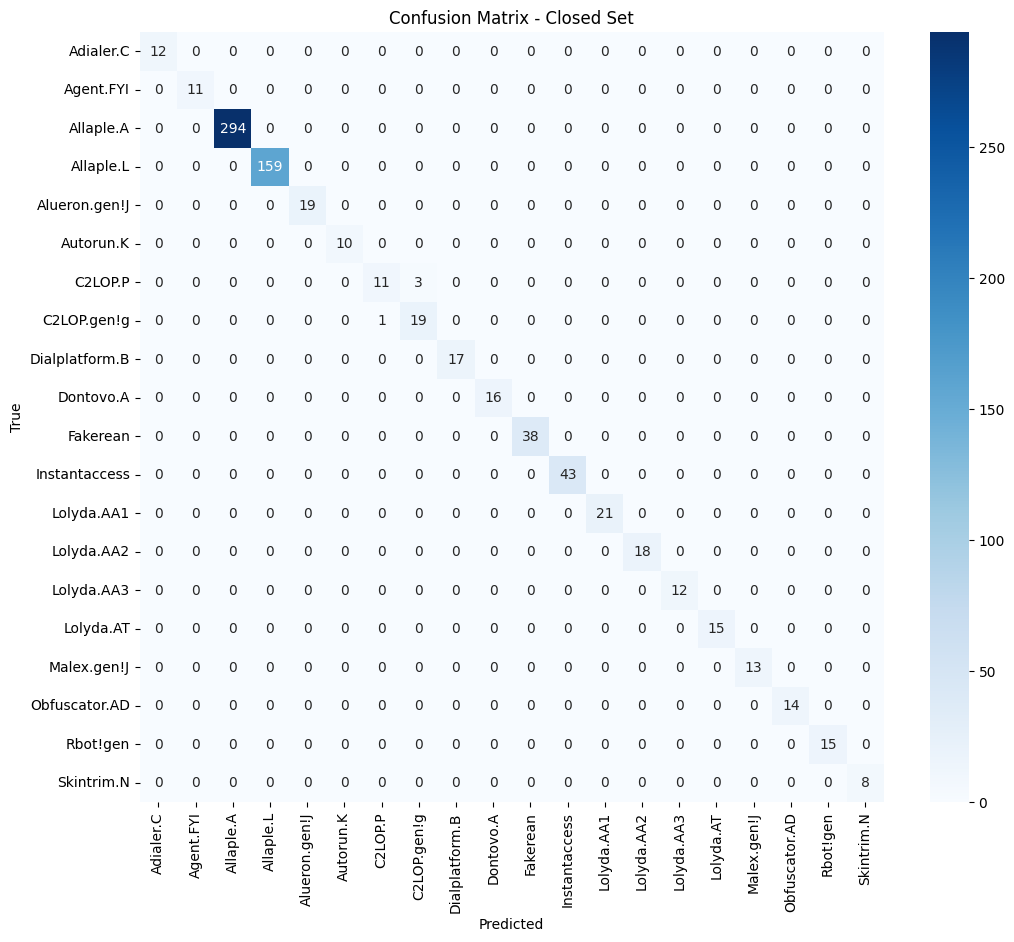

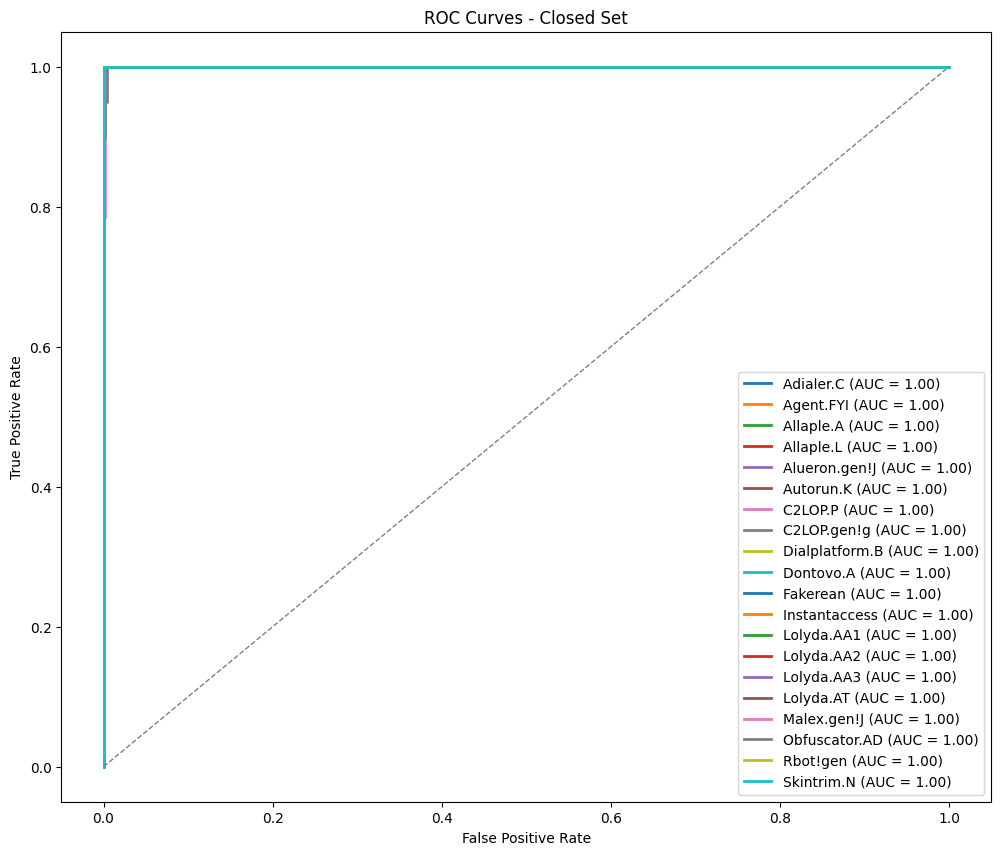

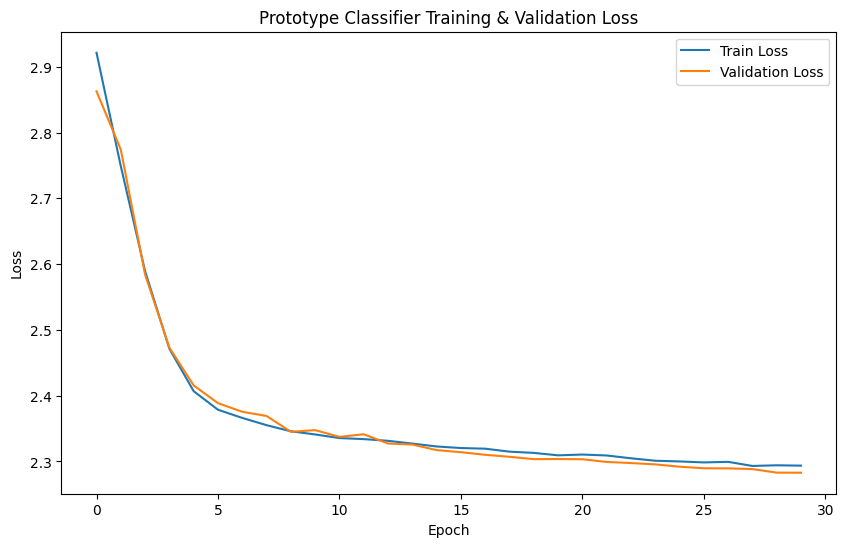


Open-set Evaluation (Test Set - Unseen Classes):
Threshold 0.70 -> Unknown Detection Rate: 0.4410
Threshold 0.72 -> Unknown Detection Rate: 0.9627
Threshold 0.75 -> Unknown Detection Rate: 1.0000
Threshold 0.78 -> Unknown Detection Rate: 1.0000
Threshold 0.80 -> Unknown Detection Rate: 1.0000


In [9]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# CONFIG
# ===============================

DATA_ROOT = "/kaggle/input/cyberresearch/malimg_dataset"
TRAIN_PATH = os.path.join(DATA_ROOT, "train")
VAL_PATH   = os.path.join(DATA_ROOT, "val")
TEST_PATH  = os.path.join(DATA_ROOT, "test")

BATCH_SIZE = 64
EPOCHS_SSL = 20
EPOCHS_PROTO = 30
TEMPERATURE = 0.5
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===============================
# TRANSFORMS (Augmentations)
# ===============================

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor()
])

# ===============================
# LOAD DATASETS
# ===============================

train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=transform)
val_dataset   = datasets.ImageFolder(VAL_PATH, transform=transform)
test_dataset  = datasets.ImageFolder(TEST_PATH, transform=transform)

classes = train_dataset.classes
num_total_classes = len(classes)
print("Total families:", num_total_classes)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ===============================
# ENCODER
# ===============================

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        self.backbone.fc = nn.Identity()
    def forward(self, x):
        return self.backbone(x)

# ===============================
# SIMCLR MODEL
# ===============================

class SimCLR(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )
    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return F.normalize(z, dim=1)

def nt_xent_loss(z1, z2, temperature=TEMPERATURE):
    batch = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2)
    sim = sim / temperature
    mask = torch.eye(batch*2, dtype=torch.bool).to(device)
    sim = sim.masked_fill(mask, -9e15)
    positives = torch.cat([torch.diag(sim, batch), torch.diag(sim, -batch)], dim=0)
    denom = torch.logsumexp(sim, dim=1)
    loss = -positives + denom
    return loss.mean()

# ===============================
# TRIPLET LOSS
# ===============================

class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin
    def forward(self, anchor, positive, negative):
        pos_dist = F.pairwise_distance(anchor, positive, p=2)
        neg_dist = F.pairwise_distance(anchor, negative, p=2)
        loss = F.relu(pos_dist - neg_dist + self.margin)
        return loss.mean()

# ===============================
# SELF-SUPERVISED PRETRAINING
# ===============================

encoder = Encoder().to(device)
simclr = SimCLR(encoder).to(device)

optimizer = optim.Adam(simclr.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

ssl_losses = []

print("\nStarting Self-Supervised Training...")
for epoch in range(EPOCHS_SSL):
    simclr.train()
    total_loss = 0
    for imgs, _ in tqdm(train_loader):
        imgs = imgs.to(device)
        x1, x2 = imgs, imgs.flip(-1)
        z1, z2 = simclr(x1), simclr(x2)
        loss = nt_xent_loss(z1, z2)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    ssl_losses.append(avg_loss)
    scheduler.step(total_loss)
    print(f"SSL Epoch {epoch+1}: {avg_loss:.4f}")

# ===============================
# PROTOTYPE CLASSIFIER
# ===============================

train_class_ids = list(range(20))  # first 20 classes

filtered_train_indices = [
    idx for idx, (_, label) in enumerate(train_dataset.samples) if label in train_class_ids
]
filtered_train_dataset = Subset(train_dataset, filtered_train_indices)
train_loader = DataLoader(filtered_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

class_counts = Counter(label for _, label in [train_dataset.samples[i] for i in filtered_train_indices])
total_samples = len(filtered_train_indices)
class_weights = [total_samples / (len(class_counts) * count) for _, count in sorted(class_counts.items())]
class_weights = torch.tensor(class_weights).to(device)

class PrototypeClassifier(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.prototypes = nn.Parameter(torch.randn(num_classes, 512))
        self.fc = nn.Linear(512, num_classes)
    def forward(self, x):
        features = self.encoder(x)
        cos_sim = F.cosine_similarity(features.unsqueeze(1), self.prototypes.unsqueeze(0), dim=2)
        return cos_sim

proto_model = PrototypeClassifier(encoder, 20).to(device)
optimizer = optim.Adam(proto_model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

proto_train_losses = []
proto_val_losses = []

print("\nTraining Prototype Classifier...")
for epoch in range(EPOCHS_PROTO):
    proto_model.train()
    total_loss = 0
    for imgs, labels in tqdm(train_loader):
        imgs, labels = imgs.to(device), labels.to(device)
        new_labels = torch.tensor([train_class_ids.index(l.item()) for l in labels]).to(device)
        outputs = proto_model(imgs)
        loss = F.cross_entropy(outputs, new_labels, weight=class_weights)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)
    proto_train_losses.append(avg_train_loss)

    # Validation loss
    proto_model.eval()
    val_loss_total = 0
    filtered_val_indices = [
        idx for idx, (_, label) in enumerate(val_dataset.samples) if label in train_class_ids
    ]
    filtered_val_dataset = Subset(val_dataset, filtered_val_indices)
    val_loader = DataLoader(filtered_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            new_labels = torch.tensor([train_class_ids.index(l.item()) for l in labels]).to(device)
            outputs = proto_model(imgs)
            val_loss_total += F.cross_entropy(outputs, new_labels, weight=class_weights).item()
    avg_val_loss = val_loss_total / len(val_loader)
    proto_val_losses.append(avg_val_loss)
    
    scheduler.step(avg_train_loss)
    print(f"Prototype Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

# ===============================
# CLOSED-SET EVALUATION
# ===============================

print("\nClosed-set Evaluation (Validation Set)...")
proto_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        new_labels = torch.tensor([train_class_ids.index(l.item()) for l in labels]).to(device)
        outputs = proto_model(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(new_labels.cpu().numpy())

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("F1 Score:", f1_score(all_labels, all_preds, average="macro"))

# ===============================
# CONFUSION MATRIX
# ===============================

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[classes[i] for i in train_class_ids],
            yticklabels=[classes[i] for i in train_class_ids])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Closed Set")
plt.show()

# ===============================
# ROC and AUC Curves
# ===============================

y_true = label_binarize(all_labels, classes=range(len(train_class_ids)))
y_score = np.zeros_like(y_true, dtype=float)

proto_model.eval()
with torch.no_grad():
    idx = 0
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = proto_model(imgs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        for i in range(probs.shape[0]):
            if idx < y_score.shape[0]:
                y_score[idx] = probs[i]
                idx += 1

plt.figure(figsize=(12,10))
for i in range(len(train_class_ids)):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{classes[train_class_ids[i]]} (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Closed Set")
plt.legend(loc="lower right")
plt.show()

# ===============================
# TRAINING & VALIDATION LOSS CURVES
# ===============================

plt.figure(figsize=(10,6))
plt.plot(proto_train_losses, label="Train Loss")
plt.plot(proto_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Prototype Classifier Training & Validation Loss")
plt.legend()
plt.show()

# ===============================
# OPEN-SET EVALUATION
# ===============================

print("\nOpen-set Evaluation (Test Set - Unseen Classes):")
thresholds = np.linspace(0.70, 0.80, 5)
unseen_class_ids = list(set(range(num_total_classes)) - set(train_class_ids))

unseen_indices = [
    idx for idx, (_, label) in enumerate(test_dataset.samples) if label in unseen_class_ids
]
unseen_dataset = Subset(test_dataset, unseen_indices)
unseen_loader = DataLoader(unseen_dataset, batch_size=BATCH_SIZE, shuffle=False)

for threshold in thresholds:
    unknown_detected, total = 0, 0
    with torch.no_grad():
        for imgs, _ in unseen_loader:
            imgs = imgs.to(device)
            outputs = proto_model(imgs)
            conf, _ = torch.max(outputs, dim=1)
            unknown_detected += torch.sum(conf < threshold).item()
            total += imgs.size(0)
    print(f"Threshold {threshold:.2f} -> Unknown Detection Rate: {unknown_detected / total:.4f}")

In [1]:
import os

# See everything available
print("=== ALL KAGGLE INPUTS ===")
for d in sorted(os.listdir("/kaggle/input")):
    print(f"  /kaggle/input/{d}")

print("\n=== FULL TREE ===")
ROOT = "/kaggle/input/cyberresearch"
for dirpath, dirnames, filenames in os.walk(ROOT):
    depth = dirpath.replace(ROOT, '').count(os.sep)
    print('  ' * depth + os.path.basename(dirpath) + '/')

=== ALL KAGGLE INPUTS ===
  /kaggle/input/cyberresearch

=== FULL TREE ===
cyberresearch/
  malimg_dataset/
    val/
      Lolyda.AA3/
      Malex.gen!J/
      C2LOP.gen!g/
      Wintrim.BX/
      Instantaccess/
      Obfuscator.AD/
      Allaple.L/
      VB.AT/
      Lolyda.AA2/
      Lolyda.AA1/
      Adialer.C/
      Dontovo.A/
      Agent.FYI/
      Skintrim.N/
      Alueron.gen!J/
      Dialplatform.B/
      Autorun.K/
      Yuner.A/
      Allaple.A/
      Swizzor.gen!E/
      Rbot!gen/
      C2LOP.P/
      Swizzor.gen!I/
      Fakerean/
      Lolyda.AT/
    test/
      Lolyda.AA3/
      Malex.gen!J/
      C2LOP.gen!g/
      Wintrim.BX/
      Instantaccess/
      Obfuscator.AD/
      Allaple.L/
      VB.AT/
      Lolyda.AA2/
      Lolyda.AA1/
      Adialer.C/
      Dontovo.A/
      Agent.FYI/
      Skintrim.N/
      Alueron.gen!J/
      Dialplatform.B/
      Autorun.K/
      Yuner.A/
      Allaple.A/
      Swizzor.gen!E/
      Rbot!gen/
      C2LOP.P/
      Swizzor.gen!I/
      Fa

Device: cuda
✅ Train | 25 classes | /kaggle/input/cyberresearch/malimg_dataset/train
✅ Val   | 25 classes | /kaggle/input/cyberresearch/malimg_dataset/val
✅ Test  | 25 classes | /kaggle/input/cyberresearch/malimg_dataset/test

Train : 25 classes | 7459 samples
Val   : 25 classes   | 923 samples
Test  : 25 classes  | 957 samples
Classes: ['Adialer.C', 'Agent.FYI', 'Allaple.A', 'Allaple.L', 'Alueron.gen!J', 'Autorun.K', 'C2LOP.P', 'C2LOP.gen!g', 'Dialplatform.B', 'Dontovo.A', 'Fakerean', 'Instantaccess', 'Lolyda.AA1', 'Lolyda.AA2', 'Lolyda.AA3', 'Lolyda.AT', 'Malex.gen!J', 'Obfuscator.AD', 'Rbot!gen', 'Skintrim.N', 'Swizzor.gen!E', 'Swizzor.gen!I', 'VB.AT', 'Wintrim.BX', 'Yuner.A']

Starting Self-Supervised Training (SimCLR)...


SSL Epoch 1/20: 100%|██████████| 117/117 [00:54<00:00,  2.15it/s]


  SSL Epoch 01/20 | Loss: 3.1307


SSL Epoch 2/20: 100%|██████████| 117/117 [00:42<00:00,  2.73it/s]


  SSL Epoch 02/20 | Loss: 2.9864


...

  SSL Epoch 18/20 | Loss: 2.9294


SSL Epoch 19/20: 100%|██████████| 117/117 [00:42<00:00,  2.73it/s]


  SSL Epoch 19/20 | Loss: 2.9244


SSL Epoch 20/20: 100%|██████████| 117/117 [00:42<00:00,  2.73it/s]


  SSL Epoch 20/20 | Loss: 2.9241


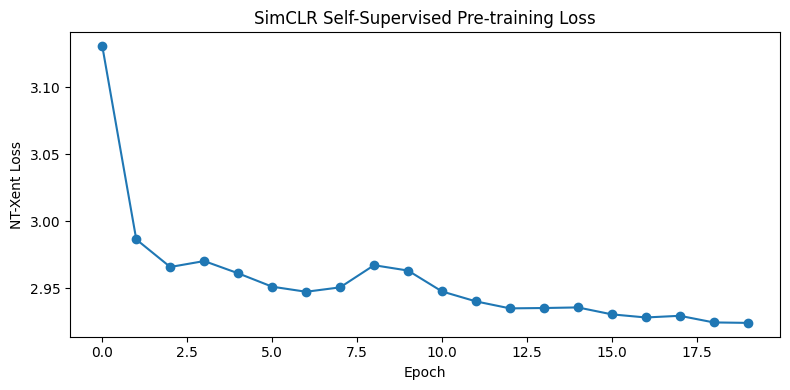


Closed-set classes : 20  → ['Adialer.C', 'Agent.FYI', 'Allaple.A', 'Allaple.L', 'Alueron.gen!J', 'Autorun.K', 'C2LOP.P', 'C2LOP.gen!g', 'Dialplatform.B', 'Dontovo.A', 'Fakerean', 'Instantaccess', 'Lolyda.AA1', 'Lolyda.AA2', 'Lolyda.AA3', 'Lolyda.AT', 'Malex.gen!J', 'Obfuscator.AD', 'Rbot!gen', 'Skintrim.N']
Open-set  classes  : 5 → ['Swizzor.gen!E', 'Swizzor.gen!I', 'VB.AT', 'Wintrim.BX', 'Yuner.A']

Training Prototype Classifier...


Proto Epoch 1/30: 100%|██████████| 98/98 [00:18<00:00,  5.29it/s]


  Proto Epoch 01/30 | Train: 2.9395 | Val: 2.8946


Proto Epoch 2/30: 100%|██████████| 98/98 [00:18<00:00,  5.37it/s]


  Proto Epoch 02/30 | Train: 2.7996 | Val: 2.7491


...

  Proto Epoch 28/30 | Train: 2.2994 | Val: 2.3152


Proto Epoch 29/30: 100%|██████████| 98/98 [00:18<00:00,  5.37it/s]


  Proto Epoch 29/30 | Train: 2.2951 | Val: 2.2822


Proto Epoch 30/30: 100%|██████████| 98/98 [00:18<00:00,  5.35it/s]


  Proto Epoch 30/30 | Train: 2.2899 | Val: 2.2772


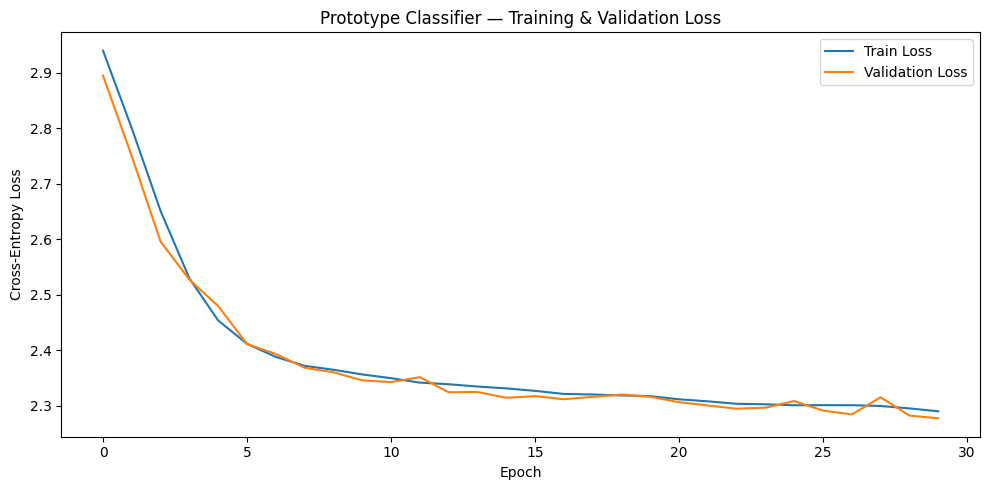


Closed-set Evaluation (Validation Set)...
Overall Accuracy : 0.9974
Overall F1 Score : 0.9939

CLASSIFICATION REPORT — Per Class (Validation Set)
                precision    recall  f1-score   support

     Adialer.C     1.0000    1.0000    1.0000        12
     Agent.FYI     1.0000    1.0000    1.0000        11
     Allaple.A     1.0000    1.0000    1.0000       294
     Allaple.L     1.0000    1.0000    1.0000       159
 Alueron.gen!J     1.0000    1.0000    1.0000        19
     Autorun.K     1.0000    1.0000    1.0000        10
       C2LOP.P     0.9286    0.9286    0.9286        14
   C2LOP.gen!g     0.9500    0.9500    0.9500        20
Dialplatform.B     1.0000    1.0000    1.0000        17
     Dontovo.A     1.0000    1.0000    1.0000        16
      Fakerean     1.0000    1.0000    1.0000        38
 Instantaccess     1.0000    1.0000    1.0000        43
    Lolyda.AA1     1.0000    1.0000    1.0000        21
    Lolyda.AA2     1.0000    1.0000    1.0000        18
    Lolyda.A

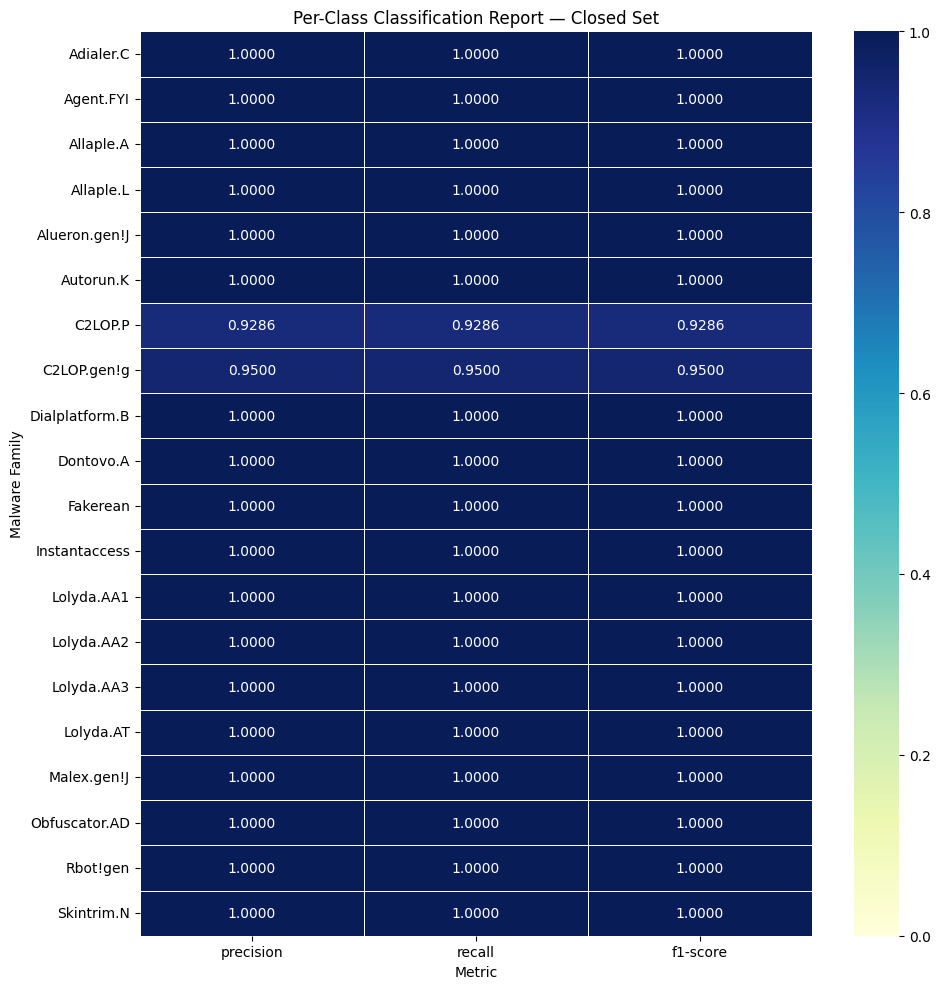

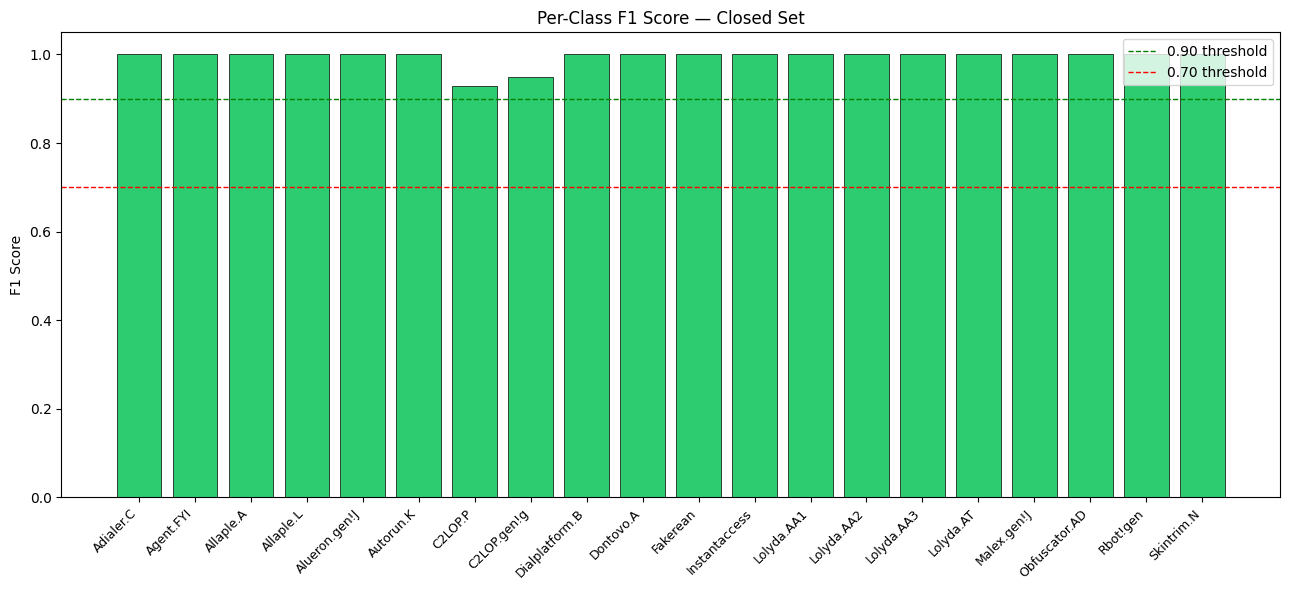

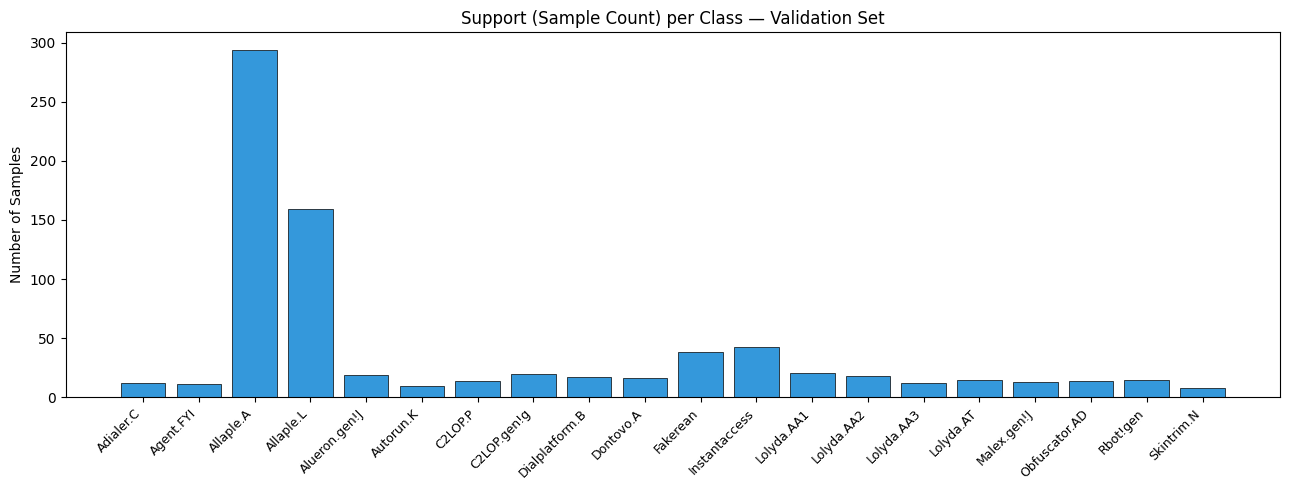

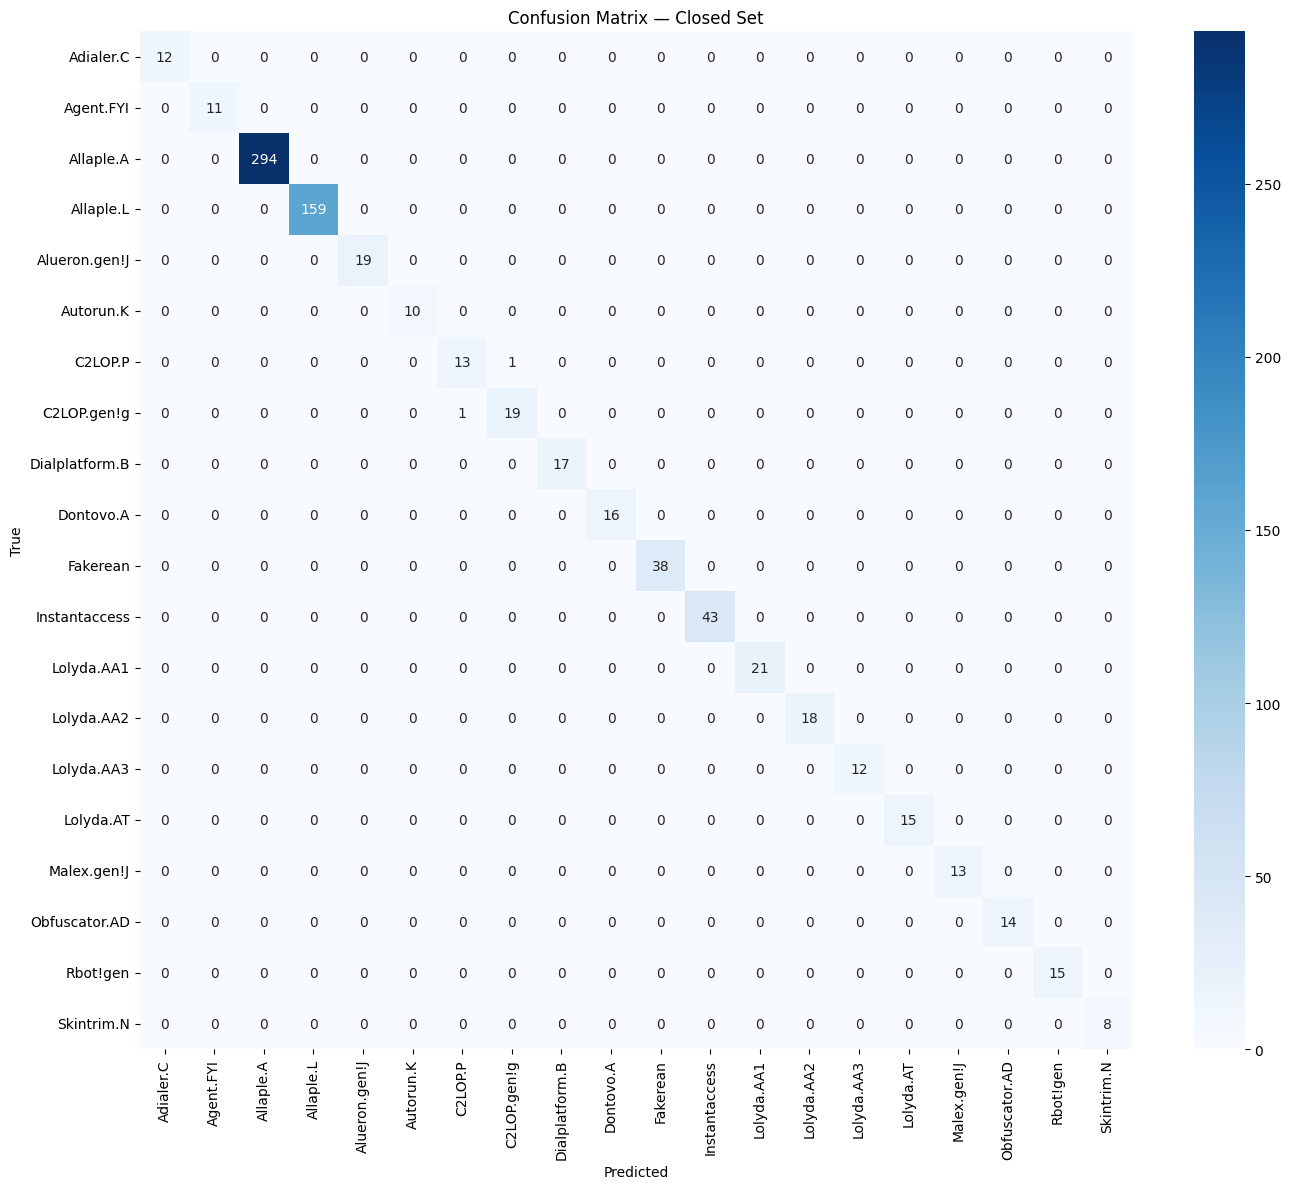

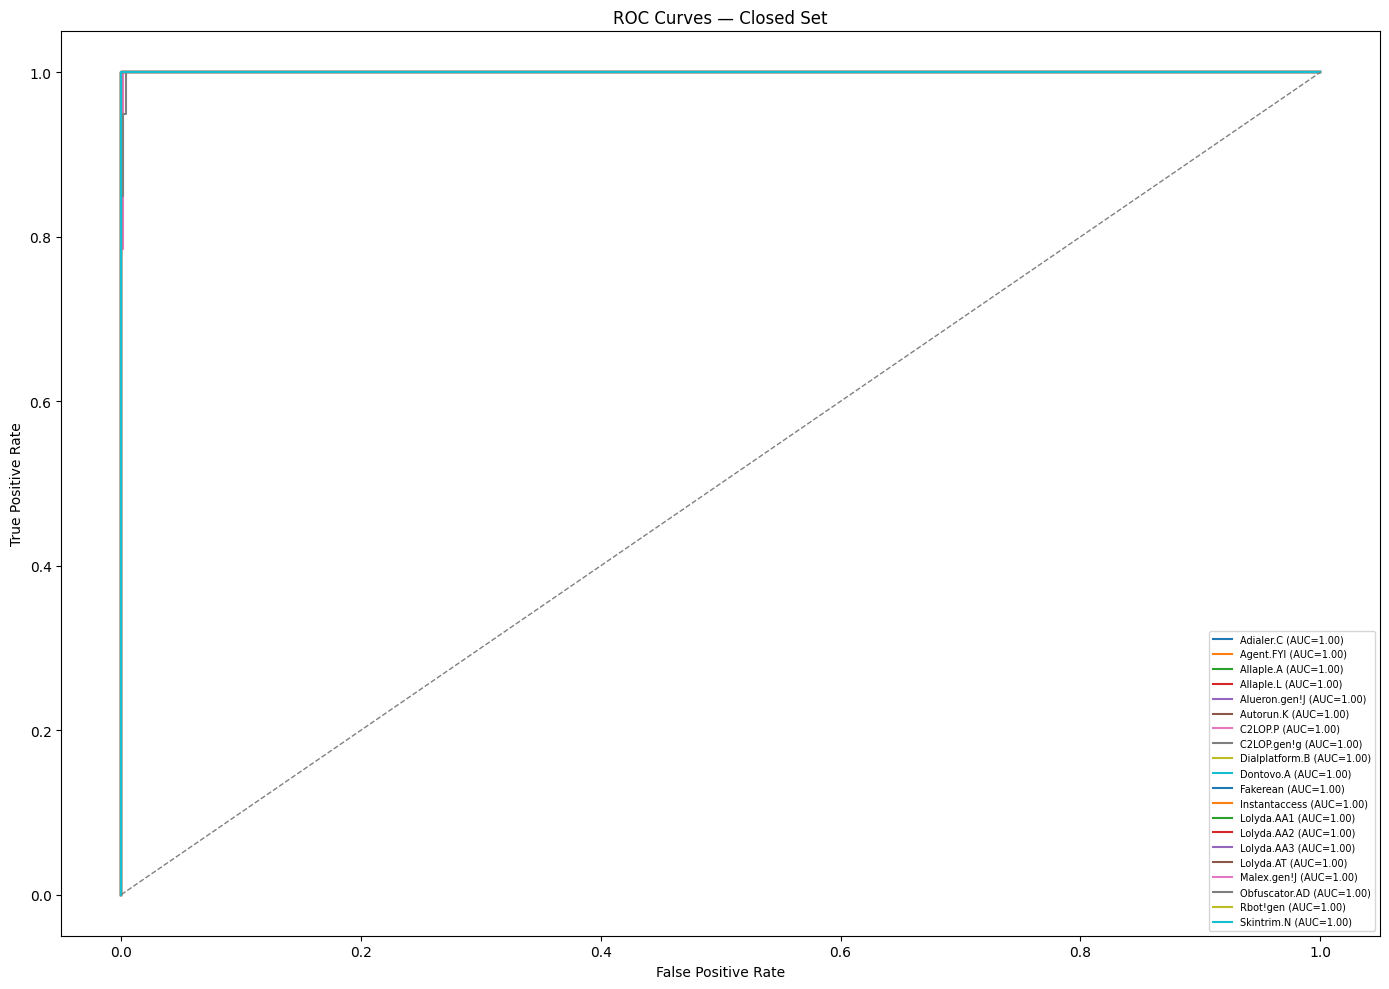


Open-set Evaluation (Test Set — Unseen Classes):
  Unseen classes      : ['Swizzor.gen!E', 'Swizzor.gen!I', 'VB.AT', 'Wintrim.BX', 'Yuner.A']
  Unseen test samples : 161

 Threshold |   Detected |   Total | Detection Rate
--------------------------------------------------
      0.70 |        142 |     161 |         0.8820
      0.72 |        161 |     161 |         1.0000
      0.75 |        161 |     161 |         1.0000
      0.78 |        161 |     161 |         1.0000
      0.80 |        161 |     161 |         1.0000


In [2]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# CONFIG
# ===============================

ROOT       = "/kaggle/input/cyberresearch/malimg_dataset"
TRAIN_PATH = os.path.join(ROOT, "train")
VAL_PATH   = os.path.join(ROOT, "val")
TEST_PATH  = os.path.join(ROOT, "test")

BATCH_SIZE   = 64
EPOCHS_SSL   = 20
EPOCHS_PROTO = 30
TEMPERATURE  = 0.5
SEED         = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Verify paths
for name, path in [("Train", TRAIN_PATH), ("Val", VAL_PATH), ("Test", TEST_PATH)]:
    exists = os.path.exists(path)
    count  = len(os.listdir(path)) if exists else 0
    print(f"{'✅' if exists else '❌'} {name:5s} | {count} classes | {path}")

# ===============================
# TRANSFORMS
# ===============================

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor()
])

# ===============================
# LOAD DATASETS
# ===============================

train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=transform)
val_dataset   = datasets.ImageFolder(VAL_PATH,   transform=transform)
test_dataset  = datasets.ImageFolder(TEST_PATH,  transform=transform)

classes           = train_dataset.classes
num_total_classes = len(classes)

print(f"\nTrain : {len(train_dataset.classes)} classes | {len(train_dataset)} samples")
print(f"Val   : {len(val_dataset.classes)} classes   | {len(val_dataset)} samples")
print(f"Test  : {len(test_dataset.classes)} classes  | {len(test_dataset)} samples")
print(f"Classes: {classes}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# ===============================
# ENCODER
# ===============================

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        self.backbone.fc = nn.Identity()

    def forward(self, x):
        return self.backbone(x)

# ===============================
# SIMCLR MODEL
# ===============================

class SimCLR(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder   = encoder
        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return F.normalize(z, dim=1)

def nt_xent_loss(z1, z2, temperature=TEMPERATURE):
    batch = z1.size(0)
    z     = torch.cat([z1, z2], dim=0)
    sim   = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2) / temperature
    mask  = torch.eye(batch * 2, dtype=torch.bool, device=device)
    sim   = sim.masked_fill(mask, -9e15)
    positives = torch.cat([torch.diag(sim, batch), torch.diag(sim, -batch)], dim=0)
    denom     = torch.logsumexp(sim, dim=1)
    return (-positives + denom).mean()

# ===============================
# TRIPLET LOSS
# ===============================

class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = F.pairwise_distance(anchor, positive, p=2)
        neg_dist = F.pairwise_distance(anchor, negative, p=2)
        return F.relu(pos_dist - neg_dist + self.margin).mean()

# ===============================
# SELF-SUPERVISED PRETRAINING
# ===============================

encoder = Encoder().to(device)
simclr  = SimCLR(encoder).to(device)

optimizer = optim.Adam(simclr.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

ssl_losses = []

print("\nStarting Self-Supervised Training (SimCLR)...")
for epoch in range(EPOCHS_SSL):
    simclr.train()
    total_loss = 0
    for imgs, _ in tqdm(train_loader, desc=f"SSL Epoch {epoch+1}/{EPOCHS_SSL}"):
        imgs   = imgs.to(device)
        z1, z2 = simclr(imgs), simclr(imgs.flip(-1))
        loss   = nt_xent_loss(z1, z2)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    ssl_losses.append(avg_loss)
    scheduler.step(total_loss)
    print(f"  SSL Epoch {epoch+1:02d}/{EPOCHS_SSL} | Loss: {avg_loss:.4f}")

# SSL Loss Plot
plt.figure(figsize=(8, 4))
plt.plot(ssl_losses, marker='o')
plt.title("SimCLR Self-Supervised Pre-training Loss")
plt.xlabel("Epoch")
plt.ylabel("NT-Xent Loss")
plt.tight_layout()
plt.show()

# ===============================
# PROTOTYPE CLASSIFIER SETUP
# ===============================

train_class_ids  = list(range(min(20, num_total_classes)))
unseen_class_ids = list(set(range(num_total_classes)) - set(train_class_ids))

print(f"\nClosed-set classes : {len(train_class_ids)}  → {[classes[i] for i in train_class_ids]}")
print(f"Open-set  classes  : {len(unseen_class_ids)} → {[classes[i] for i in unseen_class_ids]}")

# Filtered train (closed-set only)
filtered_train_indices = [
    idx for idx, (_, label) in enumerate(train_dataset.samples)
    if label in train_class_ids
]
filtered_train_dataset = Subset(train_dataset, filtered_train_indices)
train_loader_proto = DataLoader(filtered_train_dataset, batch_size=BATCH_SIZE,
                                shuffle=True, num_workers=2, pin_memory=True)

# Class-balanced weights
class_counts  = Counter(label for _, label in [train_dataset.samples[i] for i in filtered_train_indices])
total_samples = len(filtered_train_indices)
class_weights = torch.tensor(
    [total_samples / (len(class_counts) * class_counts[c]) for c in sorted(class_counts)],
    dtype=torch.float
).to(device)

# Filtered val (closed-set only)
filtered_val_indices = [
    idx for idx, (_, label) in enumerate(val_dataset.samples)
    if label in train_class_ids
]
filtered_val_dataset = Subset(val_dataset, filtered_val_indices)
val_loader_proto = DataLoader(filtered_val_dataset, batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)

# ===============================
# PROTOTYPE CLASSIFIER MODEL
# ===============================

class PrototypeClassifier(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder    = encoder
        self.prototypes = nn.Parameter(torch.randn(num_classes, 512))
        self.fc         = nn.Linear(512, num_classes)

    def forward(self, x):
        features = self.encoder(x)
        cos_sim  = F.cosine_similarity(
            features.unsqueeze(1), self.prototypes.unsqueeze(0), dim=2
        )
        return cos_sim

proto_model = PrototypeClassifier(encoder, len(train_class_ids)).to(device)
optimizer   = optim.Adam(proto_model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler   = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

proto_train_losses, proto_val_losses = [], []

# ===============================
# PROTOTYPE CLASSIFIER TRAINING
# ===============================

print("\nTraining Prototype Classifier...")
for epoch in range(EPOCHS_PROTO):
    proto_model.train()
    total_loss = 0
    for imgs, labels in tqdm(train_loader_proto, desc=f"Proto Epoch {epoch+1}/{EPOCHS_PROTO}"):
        imgs       = imgs.to(device)
        new_labels = torch.tensor(
            [train_class_ids.index(l.item()) for l in labels], device=device
        )
        loss = F.cross_entropy(proto_model(imgs), new_labels, weight=class_weights)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader_proto)
    proto_train_losses.append(avg_train_loss)

    proto_model.eval()
    val_loss_total = 0
    with torch.no_grad():
        for imgs, labels in val_loader_proto:
            imgs       = imgs.to(device)
            new_labels = torch.tensor(
                [train_class_ids.index(l.item()) for l in labels], device=device
            )
            val_loss_total += F.cross_entropy(
                proto_model(imgs), new_labels, weight=class_weights
            ).item()
    avg_val_loss = val_loss_total / len(val_loader_proto)
    proto_val_losses.append(avg_val_loss)

    scheduler.step(avg_train_loss)
    print(f"  Proto Epoch {epoch+1:02d}/{EPOCHS_PROTO} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}")

# Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(proto_train_losses, label="Train Loss")
plt.plot(proto_val_losses,   label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Prototype Classifier — Training & Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# CLOSED-SET EVALUATION
# ===============================

print("\nClosed-set Evaluation (Validation Set)...")
proto_model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in val_loader_proto:
        imgs       = imgs.to(device)
        new_labels = torch.tensor(
            [train_class_ids.index(l.item()) for l in labels], device=device
        )
        outputs = proto_model(imgs)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(new_labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds, average="macro")
print(f"Overall Accuracy : {acc:.4f}")
print(f"Overall F1 Score : {f1:.4f}")

# ===============================
# CLASSIFICATION REPORT
# ===============================

target_names = [classes[i] for i in train_class_ids]

print("\n" + "="*70)
print("CLASSIFICATION REPORT — Per Class (Validation Set)")
print("="*70)
print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))

# Parse into DataFrame
report_dict = classification_report(
    all_labels, all_preds,
    target_names=target_names,
    digits=4,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).T
report_df = report_df.loc[target_names][["precision", "recall", "f1-score", "support"]].astype(float)

print("\nPer-Class Summary Table:")
print(report_df.to_string())

# Heatmap — Precision / Recall / F1
plt.figure(figsize=(10, 10))
sns.heatmap(
    report_df[["precision", "recall", "f1-score"]],
    annot=True, fmt=".4f", cmap="YlGnBu",
    linewidths=0.5, vmin=0, vmax=1,
    yticklabels=target_names
)
plt.title("Per-Class Classification Report — Closed Set")
plt.xlabel("Metric")
plt.ylabel("Malware Family")
plt.tight_layout()
plt.show()

# Bar chart — F1 per class
colors = ["#e74c3c" if v < 0.7 else "#f39c12" if v < 0.9 else "#2ecc71"
          for v in report_df["f1-score"]]
plt.figure(figsize=(13, 6))
plt.bar(target_names, report_df["f1-score"], color=colors, edgecolor="black", linewidth=0.5)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.ylim(0, 1.05)
plt.axhline(y=0.9, color='green', linestyle='--', linewidth=1, label='0.90 threshold')
plt.axhline(y=0.7, color='red',   linestyle='--', linewidth=1, label='0.70 threshold')
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Score — Closed Set")
plt.legend()
plt.tight_layout()
plt.show()

# Bar chart — Support per class
plt.figure(figsize=(13, 5))
plt.bar(target_names, report_df["support"], color="#3498db", edgecolor="black", linewidth=0.5)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.ylabel("Number of Samples")
plt.title("Support (Sample Count) per Class — Validation Set")
plt.tight_layout()
plt.show()

# ===============================
# CONFUSION MATRIX
# ===============================

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Closed Set")
plt.tight_layout()
plt.show()

# ===============================
# ROC / AUC CURVES
# ===============================

y_true  = label_binarize(all_labels, classes=range(len(train_class_ids)))
y_score = np.array(all_probs)

plt.figure(figsize=(14, 10))
for i in range(len(train_class_ids)):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=1.5, label=f"{classes[train_class_ids[i]]} (AUC={roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Closed Set")
plt.legend(loc="lower right", fontsize=7)
plt.tight_layout()
plt.show()

# ===============================
# OPEN-SET EVALUATION
# ===============================

print("\nOpen-set Evaluation (Test Set — Unseen Classes):")

unseen_class_names = [classes[i] for i in unseen_class_ids]
unseen_test_indices = [
    idx for idx, (_, label) in enumerate(test_dataset.samples)
    if test_dataset.classes[label] in unseen_class_names
]

print(f"  Unseen classes      : {unseen_class_names}")
print(f"  Unseen test samples : {len(unseen_test_indices)}")

unseen_dataset = Subset(test_dataset, unseen_test_indices)
unseen_loader  = DataLoader(unseen_dataset, batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=2, pin_memory=True)

thresholds = np.linspace(0.70, 0.80, 5)
proto_model.eval()

print(f"\n{'Threshold':>10} | {'Detected':>10} | {'Total':>7} | {'Detection Rate':>14}")
print("-" * 50)
for threshold in thresholds:
    unknown_detected, total = 0, 0
    with torch.no_grad():
        for imgs, _ in unseen_loader:
            imgs = imgs.to(device)
            conf, _ = torch.max(proto_model(imgs), dim=1)
            unknown_detected += (conf < threshold).sum().item()
            total += imgs.size(0)
    rate = unknown_detected / total if total > 0 else 0.0
    print(f"{threshold:>10.2f} | {unknown_detected:>10} | {total:>7} | {rate:>14.4f}")

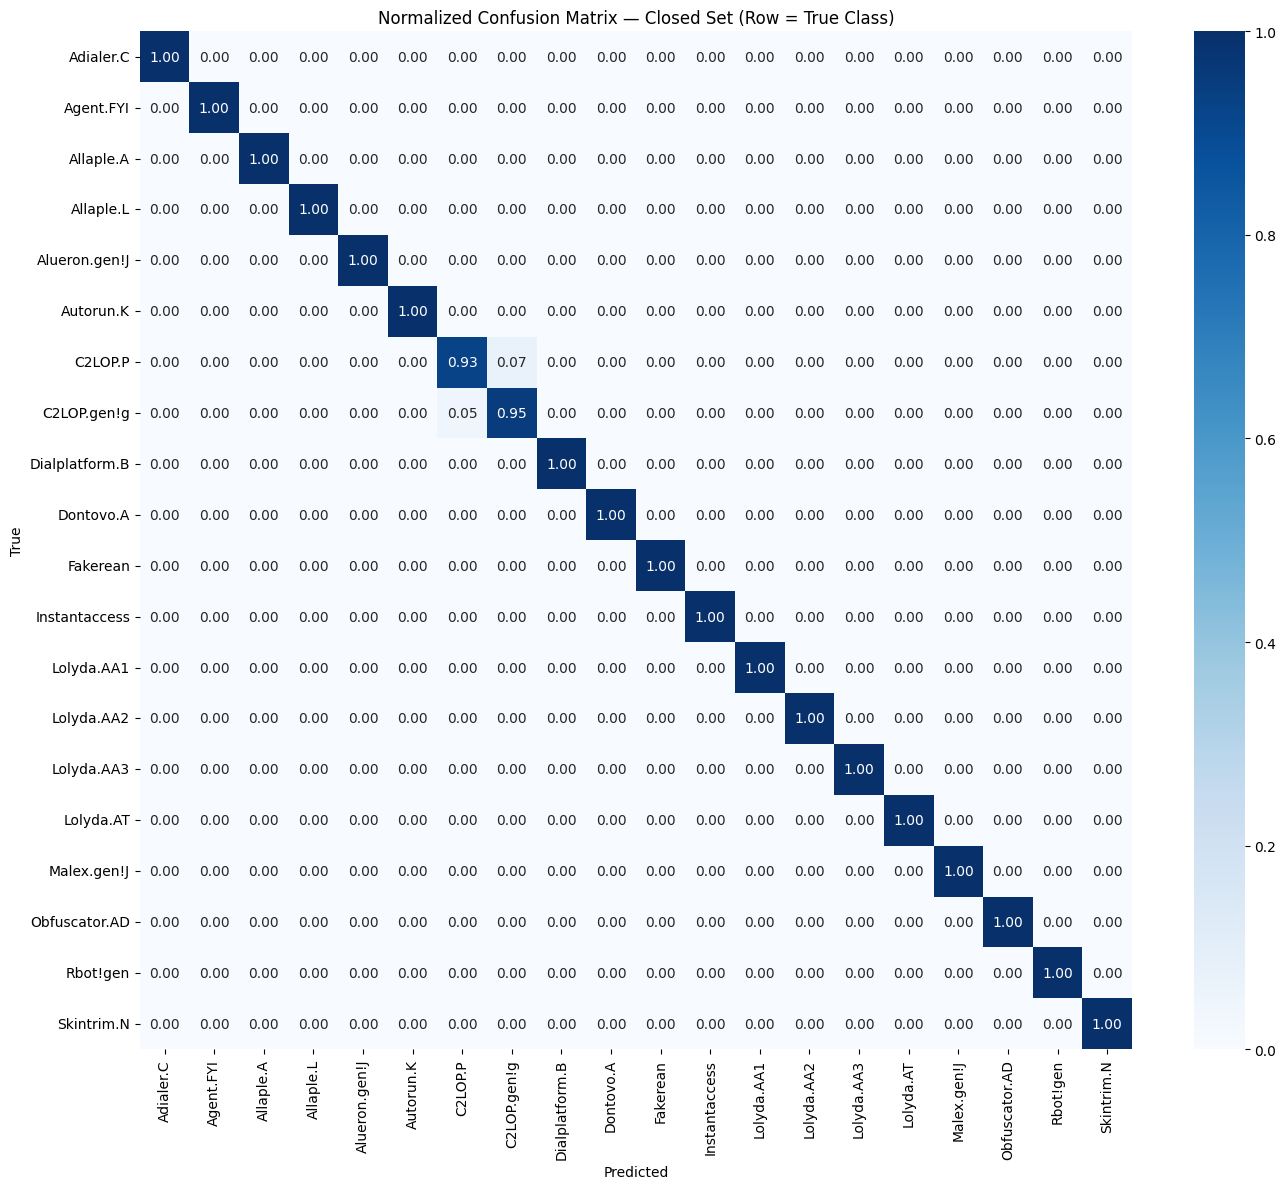

In [3]:
# ===============================
# NORMALIZED CONFUSION MATRIX
# ===============================

# Normalize by true labels (row-wise) — shows recall per class
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    vmin=0,
    vmax=1
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix — Closed Set (Row = True Class)")
plt.tight_layout()
plt.show()

Device: cuda
✅ Train | 25 classes | /kaggle/input/cyberresearch/malimg_dataset/train
✅ Val   | 25 classes | /kaggle/input/cyberresearch/malimg_dataset/val
✅ Test  | 25 classes | /kaggle/input/cyberresearch/malimg_dataset/test

Train : 25 classes | 7459 samples
Val   : 25 classes   | 923 samples
Test  : 25 classes  | 957 samples
Classes: ['Adialer.C', 'Agent.FYI', 'Allaple.A', 'Allaple.L', 'Alueron.gen!J', 'Autorun.K', 'C2LOP.P', 'C2LOP.gen!g', 'Dialplatform.B', 'Dontovo.A', 'Fakerean', 'Instantaccess', 'Lolyda.AA1', 'Lolyda.AA2', 'Lolyda.AA3', 'Lolyda.AT', 'Malex.gen!J', 'Obfuscator.AD', 'Rbot!gen', 'Skintrim.N', 'Swizzor.gen!E', 'Swizzor.gen!I', 'VB.AT', 'Wintrim.BX', 'Yuner.A']

Starting Self-Supervised Training (SimCLR)...


SSL Epoch 1/20: 100%|██████████| 117/117 [00:53<00:00,  2.18it/s]


  SSL Epoch 01/20 | Loss: 3.1285


SSL Epoch 2/20: 100%|██████████| 117/117 [00:40<00:00,  2.89it/s]


  SSL Epoch 02/20 | Loss: 2.9888


...

  SSL Epoch 18/20 | Loss: 2.9302


SSL Epoch 19/20: 100%|██████████| 117/117 [00:46<00:00,  2.54it/s]


  SSL Epoch 19/20 | Loss: 2.9284


SSL Epoch 20/20: 100%|██████████| 117/117 [00:45<00:00,  2.55it/s]


  SSL Epoch 20/20 | Loss: 2.9355


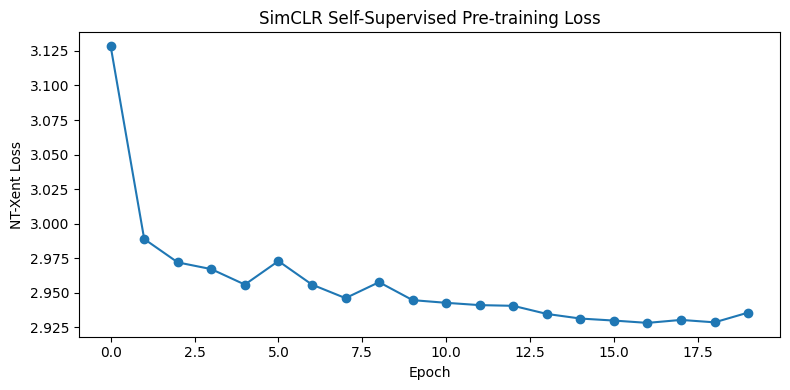


Closed-set classes : 20  → ['Adialer.C', 'Agent.FYI', 'Allaple.A', 'Allaple.L', 'Alueron.gen!J', 'Autorun.K', 'C2LOP.P', 'C2LOP.gen!g', 'Dialplatform.B', 'Dontovo.A', 'Fakerean', 'Instantaccess', 'Lolyda.AA1', 'Lolyda.AA2', 'Lolyda.AA3', 'Lolyda.AT', 'Malex.gen!J', 'Obfuscator.AD', 'Rbot!gen', 'Skintrim.N']
Open-set  classes  : 5 → ['Swizzor.gen!E', 'Swizzor.gen!I', 'VB.AT', 'Wintrim.BX', 'Yuner.A']

Training Prototype Classifier...


Proto Epoch 1/30: 100%|██████████| 98/98 [00:19<00:00,  5.04it/s]


  Proto Epoch 01/30 | Train: 2.9366 | Val: 2.8721


Proto Epoch 2/30: 100%|██████████| 98/98 [00:19<00:00,  5.06it/s]


  Proto Epoch 02/30 | Train: 2.8011 | Val: 2.7541


...

  Proto Epoch 28/30 | Train: 2.2984 | Val: 2.2749


Proto Epoch 29/30: 100%|██████████| 98/98 [00:19<00:00,  5.09it/s]


  Proto Epoch 29/30 | Train: 2.2950 | Val: 2.2741


Proto Epoch 30/30: 100%|██████████| 98/98 [00:19<00:00,  5.09it/s]


  Proto Epoch 30/30 | Train: 2.2904 | Val: 2.2713


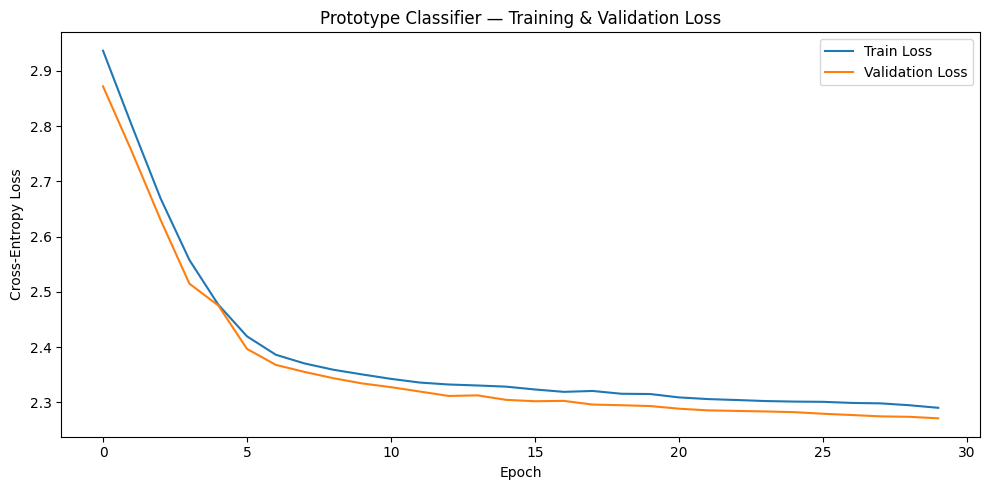


Closed-set Evaluation (Validation Set)...
Overall Accuracy : 0.9961
Overall F1 Score : 0.9905

CLASSIFICATION REPORT — Per Class (Validation Set)
                precision    recall  f1-score   support

     Adialer.C     1.0000    1.0000    1.0000        12
     Agent.FYI     1.0000    1.0000    1.0000        11
     Allaple.A     1.0000    1.0000    1.0000       294
     Allaple.L     1.0000    1.0000    1.0000       159
 Alueron.gen!J     1.0000    1.0000    1.0000        19
     Autorun.K     1.0000    1.0000    1.0000        10
       C2LOP.P     1.0000    0.7857    0.8800        14
   C2LOP.gen!g     0.8696    1.0000    0.9302        20
Dialplatform.B     1.0000    1.0000    1.0000        17
     Dontovo.A     1.0000    1.0000    1.0000        16
      Fakerean     1.0000    1.0000    1.0000        38
 Instantaccess     1.0000    1.0000    1.0000        43
    Lolyda.AA1     1.0000    1.0000    1.0000        21
    Lolyda.AA2     1.0000    1.0000    1.0000        18
    Lolyda.A

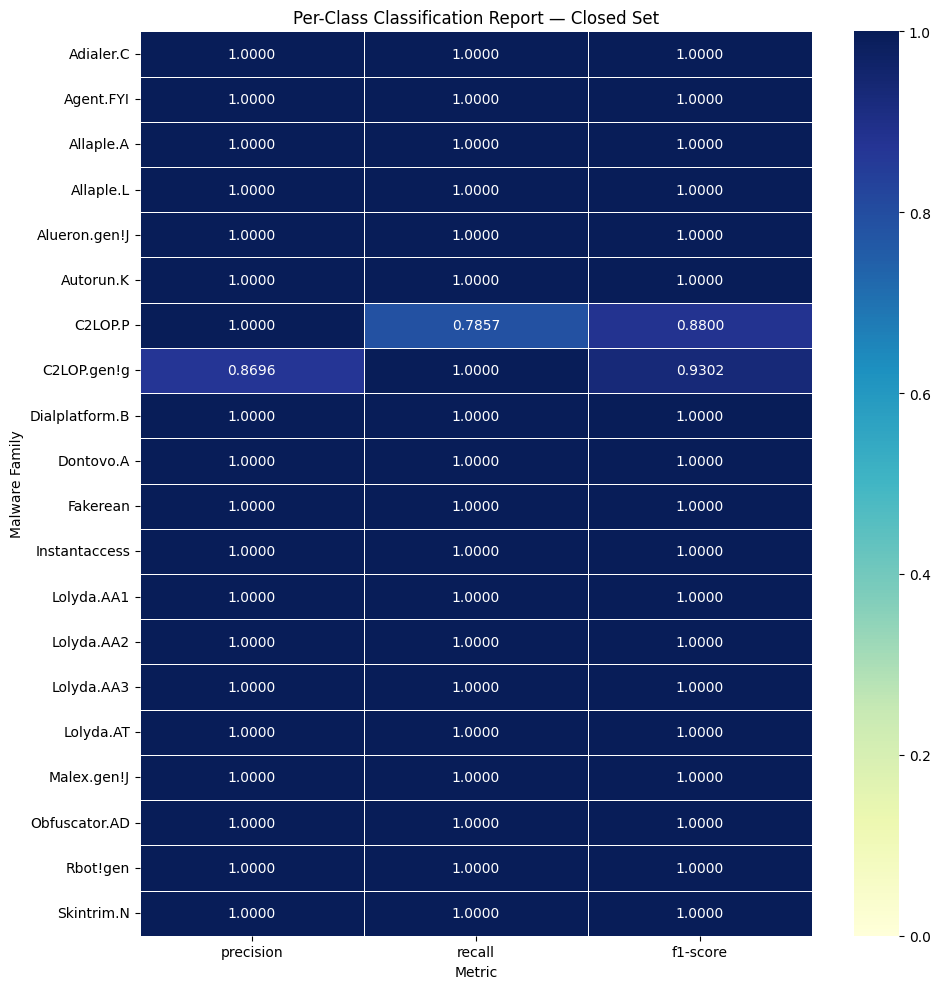

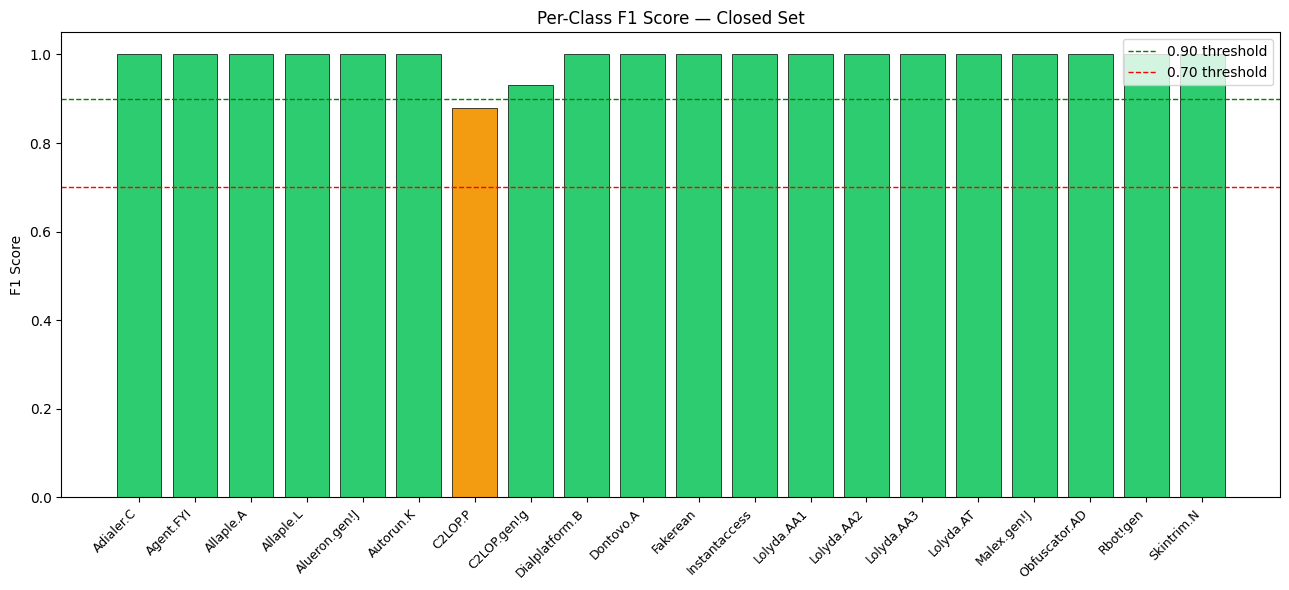

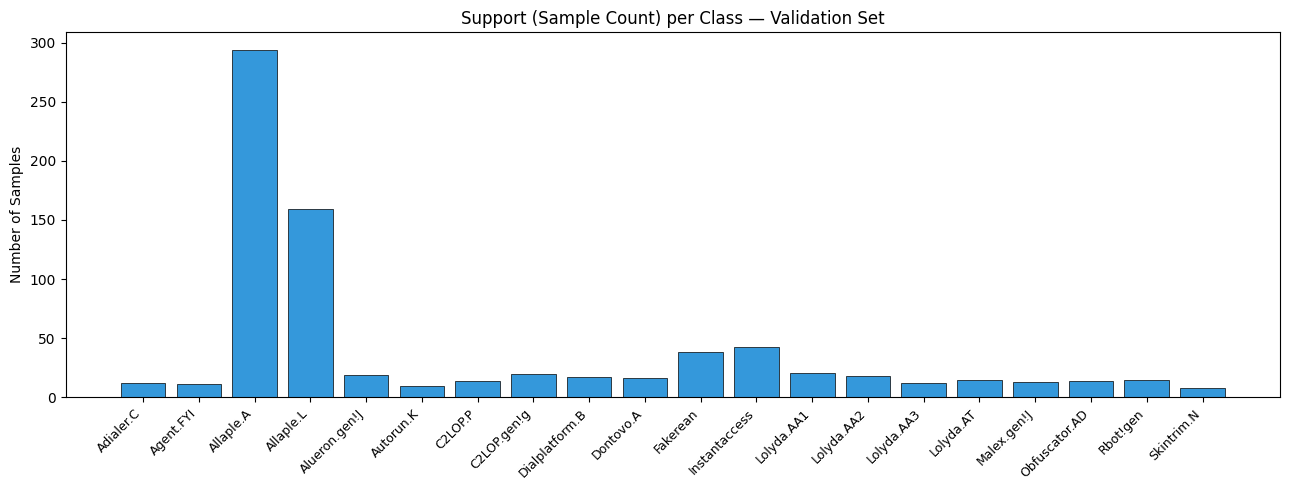

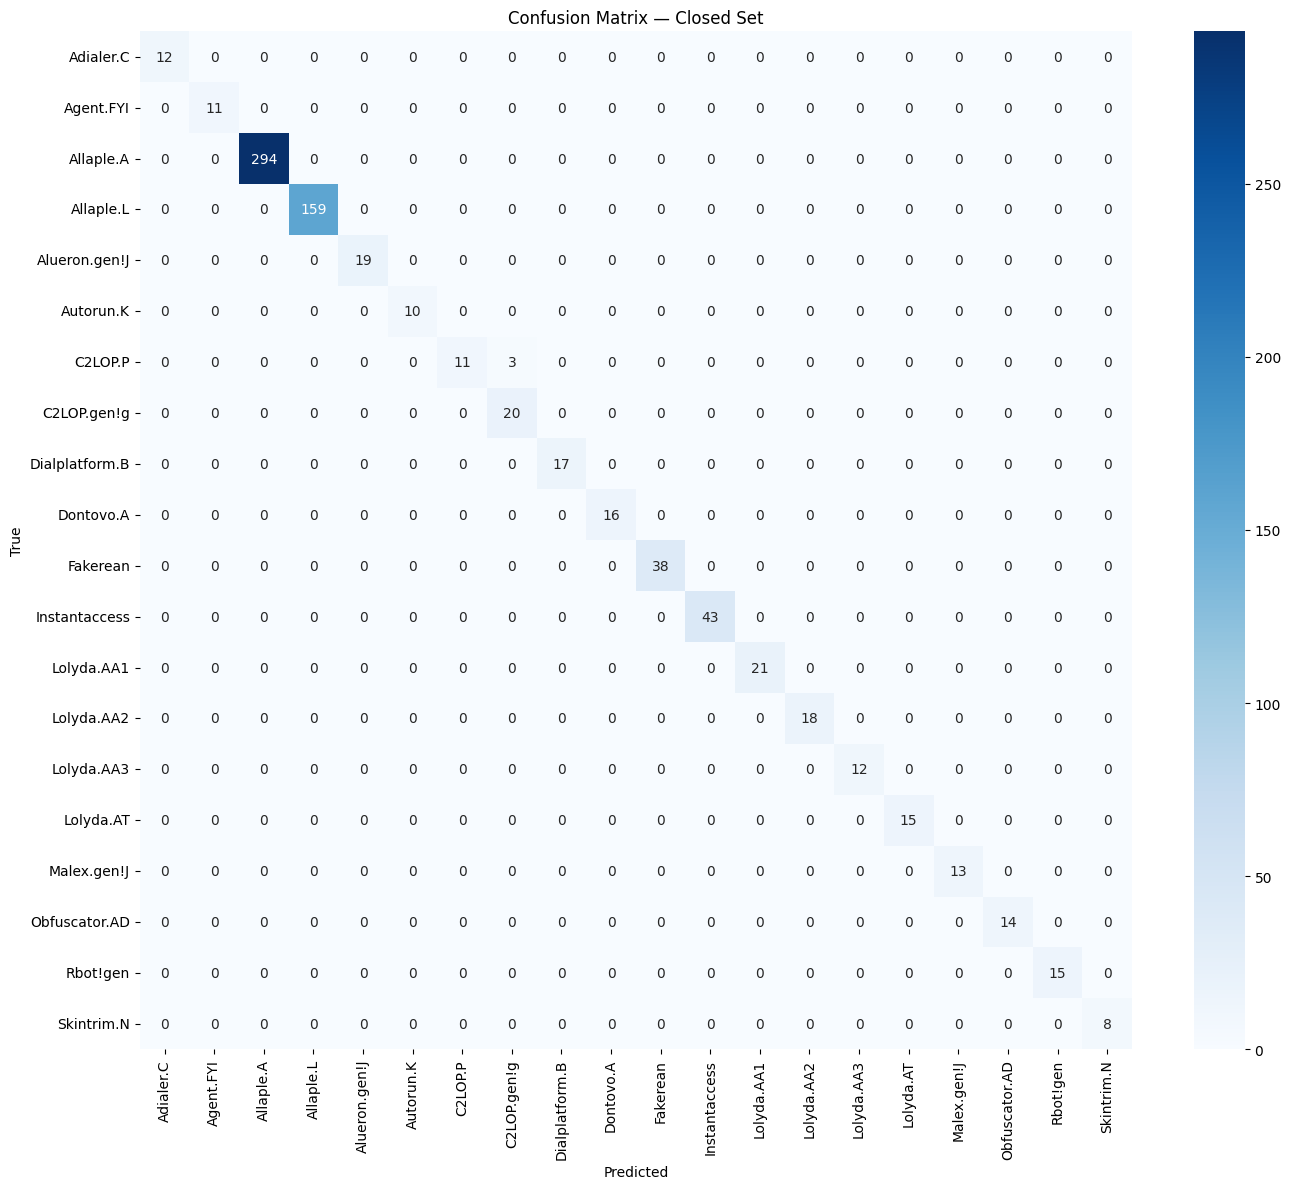

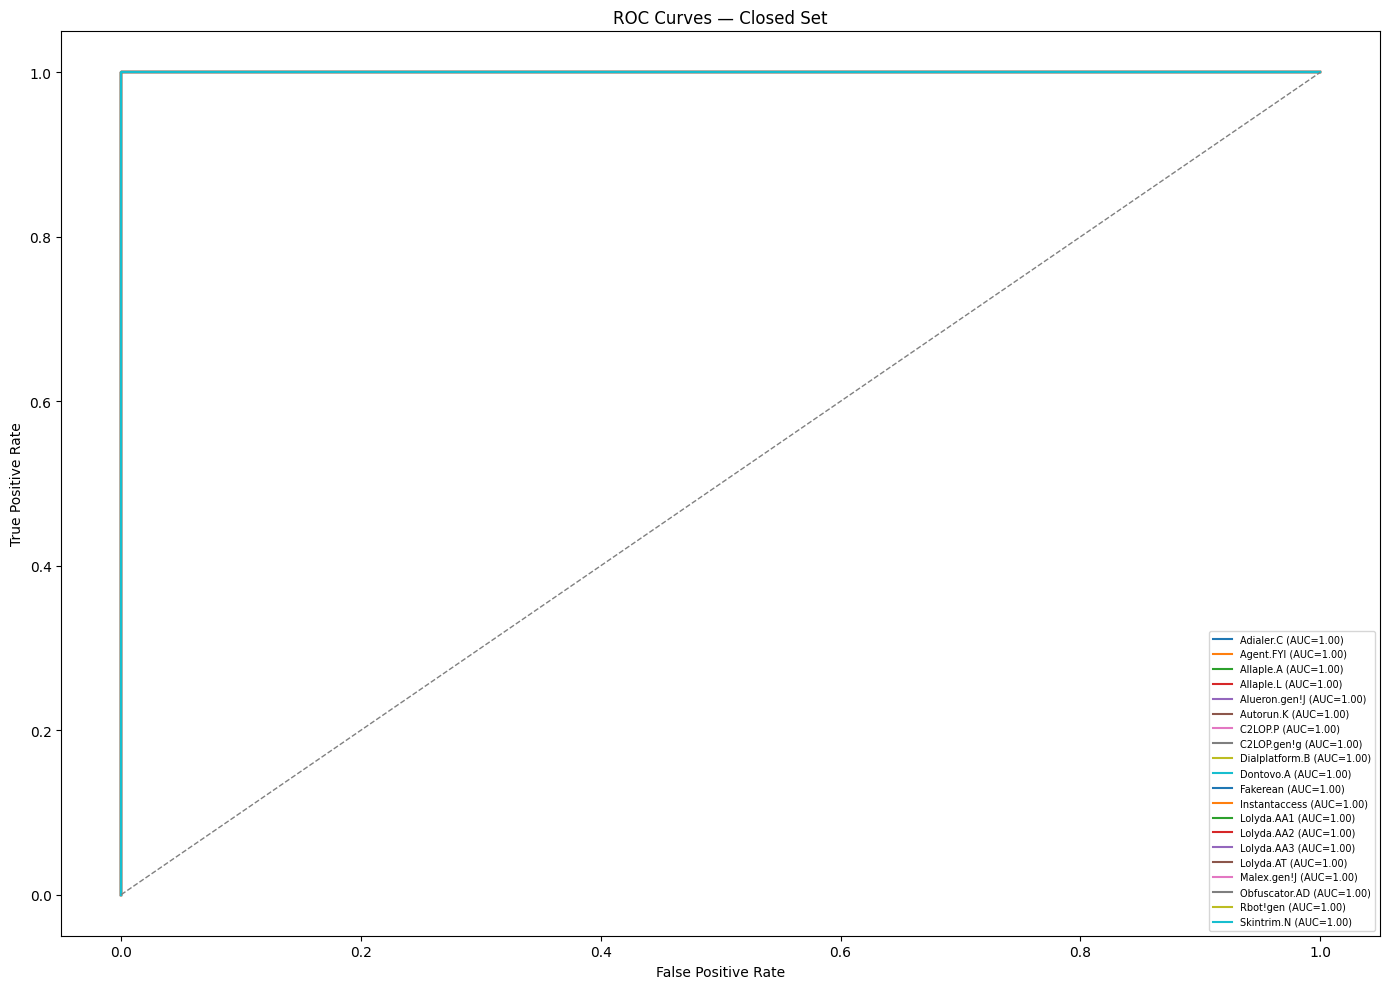


Open-set Evaluation (Threshold Sweep)...
  Unseen classes      : ['Swizzor.gen!E', 'Swizzor.gen!I', 'VB.AT', 'Wintrim.BX', 'Yuner.A']
  Unseen test samples : 161

Threshold Sweep Results:
 threshold  known_accept_rate  known_reject_rate  known_acc_with_rejection  closed_set_acc_on_accepted  unknown_reject_rate  unknown_false_accept_rate  balanced_binary_score  balanced_open_set_score
      0.50             1.0000             0.0000                    0.9961                      0.9961               0.0932                     0.9068                 0.5466                   0.5446
      0.55             0.9987             0.0013                    0.9961                      0.9974               0.1491                     0.8509                 0.5739                   0.5726
      0.60             0.9961             0.0039                    0.9961                      1.0000               0.2484                     0.7516                 0.6223                   0.6223
      0.65     

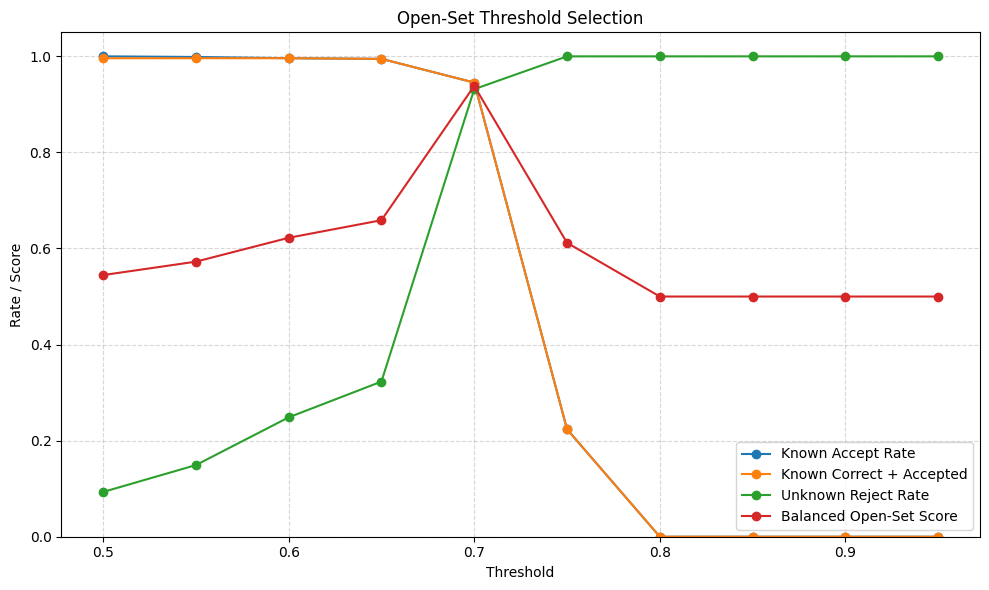


Final Open-set Result Using Best Threshold
Best Threshold = 0.7000
Unknown samples rejected: 150/161
Final Unknown Rejection Rate: 0.9317


In [1]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, roc_curve, auc,
    classification_report
)
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# CONFIG
# ===============================

ROOT       = "/kaggle/input/cyberresearch/malimg_dataset"
TRAIN_PATH = os.path.join(ROOT, "train")
VAL_PATH   = os.path.join(ROOT, "val")
TEST_PATH  = os.path.join(ROOT, "test")

BATCH_SIZE   = 64
EPOCHS_SSL   = 20
EPOCHS_PROTO = 30
TEMPERATURE  = 0.5
SEED         = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Verify paths
for name, path in [("Train", TRAIN_PATH), ("Val", VAL_PATH), ("Test", TEST_PATH)]:
    exists = os.path.exists(path)
    count  = len(os.listdir(path)) if exists else 0
    print(f"{'✅' if exists else '❌'} {name:5s} | {count} classes | {path}")

# ===============================
# TRANSFORMS
# ===============================

train_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor()
])

eval_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# ===============================
# LOAD DATASETS
# ===============================

train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_PATH,   transform=eval_transform)
test_dataset  = datasets.ImageFolder(TEST_PATH,  transform=eval_transform)

classes           = train_dataset.classes
num_total_classes = len(classes)

print(f"\nTrain : {len(train_dataset.classes)} classes | {len(train_dataset)} samples")
print(f"Val   : {len(val_dataset.classes)} classes   | {len(val_dataset)} samples")
print(f"Test  : {len(test_dataset.classes)} classes  | {len(test_dataset)} samples")
print(f"Classes: {classes}")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

# ===============================
# ENCODER
# ===============================

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        self.backbone.fc = nn.Identity()

    def forward(self, x):
        return self.backbone(x)

# ===============================
# SIMCLR MODEL
# ===============================

class SimCLR(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder   = encoder
        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return F.normalize(z, dim=1)

def nt_xent_loss(z1, z2, temperature=TEMPERATURE):
    batch = z1.size(0)
    z     = torch.cat([z1, z2], dim=0)
    sim   = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2) / temperature
    mask  = torch.eye(batch * 2, dtype=torch.bool, device=device)
    sim   = sim.masked_fill(mask, -9e15)
    positives = torch.cat([torch.diag(sim, batch), torch.diag(sim, -batch)], dim=0)
    denom     = torch.logsumexp(sim, dim=1)
    return (-positives + denom).mean()

# ===============================
# TRIPLET LOSS
# ===============================

class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = F.pairwise_distance(anchor, positive, p=2)
        neg_dist = F.pairwise_distance(anchor, negative, p=2)
        return F.relu(pos_dist - neg_dist + self.margin).mean()

# ===============================
# SELF-SUPERVISED PRETRAINING
# ===============================

encoder = Encoder().to(device)
simclr  = SimCLR(encoder).to(device)

optimizer = optim.Adam(simclr.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

ssl_losses = []

print("\nStarting Self-Supervised Training (SimCLR)...")
for epoch in range(EPOCHS_SSL):
    simclr.train()
    total_loss = 0
    for imgs, _ in tqdm(train_loader, desc=f"SSL Epoch {epoch+1}/{EPOCHS_SSL}"):
        imgs   = imgs.to(device)
        z1, z2 = simclr(imgs), simclr(imgs.flip(-1))
        loss   = nt_xent_loss(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    ssl_losses.append(avg_loss)
    scheduler.step(total_loss)
    print(f"  SSL Epoch {epoch+1:02d}/{EPOCHS_SSL} | Loss: {avg_loss:.4f}")

# SSL Loss Plot
plt.figure(figsize=(8, 4))
plt.plot(ssl_losses, marker='o')
plt.title("SimCLR Self-Supervised Pre-training Loss")
plt.xlabel("Epoch")
plt.ylabel("NT-Xent Loss")
plt.tight_layout()
plt.show()

# ===============================
# PROTOTYPE CLASSIFIER SETUP
# ===============================

train_class_ids  = list(range(min(20, num_total_classes)))
unseen_class_ids = list(set(range(num_total_classes)) - set(train_class_ids))

print(f"\nClosed-set classes : {len(train_class_ids)}  → {[classes[i] for i in train_class_ids]}")
print(f"Open-set  classes  : {len(unseen_class_ids)} → {[classes[i] for i in unseen_class_ids]}")

# Filtered train (closed-set only)
filtered_train_indices = [
    idx for idx, (_, label) in enumerate(train_dataset.samples)
    if label in train_class_ids
]
filtered_train_dataset = Subset(train_dataset, filtered_train_indices)
train_loader_proto = DataLoader(
    filtered_train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True
)

# Class-balanced weights
class_counts  = Counter(label for _, label in [train_dataset.samples[i] for i in filtered_train_indices])
total_samples = len(filtered_train_indices)
class_weights = torch.tensor(
    [total_samples / (len(class_counts) * class_counts[c]) for c in sorted(class_counts)],
    dtype=torch.float
).to(device)

# Filtered val (closed-set only)
filtered_val_indices = [
    idx for idx, (_, label) in enumerate(val_dataset.samples)
    if label in train_class_ids
]
filtered_val_dataset = Subset(val_dataset, filtered_val_indices)
val_loader_proto = DataLoader(
    filtered_val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

# ===============================
# PROTOTYPE CLASSIFIER MODEL
# ===============================

class PrototypeClassifier(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder    = encoder
        self.prototypes = nn.Parameter(torch.randn(num_classes, 512))
        self.fc         = nn.Linear(512, num_classes)  # unused, kept to match your original code

    def forward(self, x):
        features = self.encoder(x)
        cos_sim  = F.cosine_similarity(
            features.unsqueeze(1), self.prototypes.unsqueeze(0), dim=2
        )
        return cos_sim

proto_model = PrototypeClassifier(encoder, len(train_class_ids)).to(device)
optimizer   = optim.Adam(proto_model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler   = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

proto_train_losses, proto_val_losses = [], []

# ===============================
# PROTOTYPE CLASSIFIER TRAINING
# ===============================

print("\nTraining Prototype Classifier...")
for epoch in range(EPOCHS_PROTO):
    proto_model.train()
    total_loss = 0

    for imgs, labels in tqdm(train_loader_proto, desc=f"Proto Epoch {epoch+1}/{EPOCHS_PROTO}"):
        imgs = imgs.to(device)
        new_labels = torch.tensor(
            [train_class_ids.index(l.item()) for l in labels], device=device
        )

        loss = F.cross_entropy(proto_model(imgs), new_labels, weight=class_weights)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader_proto)
    proto_train_losses.append(avg_train_loss)

    proto_model.eval()
    val_loss_total = 0
    with torch.no_grad():
        for imgs, labels in val_loader_proto:
            imgs = imgs.to(device)
            new_labels = torch.tensor(
                [train_class_ids.index(l.item()) for l in labels], device=device
            )
            val_loss_total += F.cross_entropy(
                proto_model(imgs), new_labels, weight=class_weights
            ).item()

    avg_val_loss = val_loss_total / len(val_loader_proto)
    proto_val_losses.append(avg_val_loss)

    scheduler.step(avg_train_loss)
    print(f"  Proto Epoch {epoch+1:02d}/{EPOCHS_PROTO} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}")

# Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(proto_train_losses, label="Train Loss")
plt.plot(proto_val_losses,   label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Prototype Classifier — Training & Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# CLOSED-SET EVALUATION
# ===============================

print("\nClosed-set Evaluation (Validation Set)...")
proto_model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in val_loader_proto:
        imgs = imgs.to(device)
        new_labels = torch.tensor(
            [train_class_ids.index(l.item()) for l in labels], device=device
        )
        outputs = proto_model(imgs)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(new_labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds, average="macro")
print(f"Overall Accuracy : {acc:.4f}")
print(f"Overall F1 Score : {f1:.4f}")

# ===============================
# CLASSIFICATION REPORT
# ===============================

target_names = [classes[i] for i in train_class_ids]

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT — Per Class (Validation Set)")
print("=" * 70)
print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))

report_dict = classification_report(
    all_labels, all_preds,
    target_names=target_names,
    digits=4,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).T
report_df = report_df.loc[target_names][["precision", "recall", "f1-score", "support"]].astype(float)

print("\nPer-Class Summary Table:")
print(report_df.to_string())

# Heatmap — Precision / Recall / F1
plt.figure(figsize=(10, 10))
sns.heatmap(
    report_df[["precision", "recall", "f1-score"]],
    annot=True, fmt=".4f", cmap="YlGnBu",
    linewidths=0.5, vmin=0, vmax=1,
    yticklabels=target_names
)
plt.title("Per-Class Classification Report — Closed Set")
plt.xlabel("Metric")
plt.ylabel("Malware Family")
plt.tight_layout()
plt.show()

# Bar chart — F1 per class
colors = ["#e74c3c" if v < 0.7 else "#f39c12" if v < 0.9 else "#2ecc71"
          for v in report_df["f1-score"]]
plt.figure(figsize=(13, 6))
plt.bar(target_names, report_df["f1-score"], color=colors, edgecolor="black", linewidth=0.5)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.ylim(0, 1.05)
plt.axhline(y=0.9, color='green', linestyle='--', linewidth=1, label='0.90 threshold')
plt.axhline(y=0.7, color='red',   linestyle='--', linewidth=1, label='0.70 threshold')
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Score — Closed Set")
plt.legend()
plt.tight_layout()
plt.show()

# Bar chart — Support per class
plt.figure(figsize=(13, 5))
plt.bar(target_names, report_df["support"], color="#3498db", edgecolor="black", linewidth=0.5)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.ylabel("Number of Samples")
plt.title("Support (Sample Count) per Class — Validation Set")
plt.tight_layout()
plt.show()

# ===============================
# CONFUSION MATRIX
# ===============================

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Closed Set")
plt.tight_layout()
plt.show()

# ===============================
# ROC / AUC CURVES
# ===============================

y_true  = label_binarize(all_labels, classes=range(len(train_class_ids)))
y_score = np.array(all_probs)

plt.figure(figsize=(14, 10))
for i in range(len(train_class_ids)):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=1.5, label=f"{classes[train_class_ids[i]]} (AUC={roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Closed Set")
plt.legend(loc="lower right", fontsize=7)
plt.tight_layout()
plt.show()

# ===============================
# OPEN-SET THRESHOLD EVALUATION
# ===============================

def evaluate_open_set_thresholds(
    proto_model,
    known_loader,
    unknown_loader,
    train_class_ids,
    device,
    thresholds=np.linspace(0.50, 0.95, 10)
):
    proto_model.eval()
    results = []

    for threshold in thresholds:
        # -------------------------
        # Known-set evaluation
        # -------------------------
        known_total = 0
        known_accepted = 0
        known_rejected = 0
        known_correct_and_accepted = 0

        with torch.no_grad():
            for imgs, labels in known_loader:
                imgs = imgs.to(device)
                new_labels = torch.tensor(
                    [train_class_ids.index(l.item()) for l in labels],
                    device=device
                )

                outputs = proto_model(imgs)  # cosine similarities
                conf, preds = torch.max(outputs, dim=1)

                accepted_mask = conf >= threshold
                rejected_mask = conf < threshold

                known_total += imgs.size(0)
                known_accepted += accepted_mask.sum().item()
                known_rejected += rejected_mask.sum().item()
                known_correct_and_accepted += ((preds == new_labels) & accepted_mask).sum().item()

        known_accept_rate = known_accepted / known_total if known_total > 0 else 0.0
        known_reject_rate = known_rejected / known_total if known_total > 0 else 0.0
        known_acc_with_rejection = known_correct_and_accepted / known_total if known_total > 0 else 0.0
        closed_set_acc_on_accepted = (
            known_correct_and_accepted / known_accepted if known_accepted > 0 else 0.0
        )

        # -------------------------
        # Unknown-set evaluation
        # -------------------------
        unknown_total = 0
        unknown_rejected = 0
        unknown_accepted = 0

        with torch.no_grad():
            for imgs, _ in unknown_loader:
                imgs = imgs.to(device)

                outputs = proto_model(imgs)  # cosine similarities
                conf, _ = torch.max(outputs, dim=1)

                rejected_mask = conf < threshold
                accepted_mask = conf >= threshold

                unknown_total += imgs.size(0)
                unknown_rejected += rejected_mask.sum().item()
                unknown_accepted += accepted_mask.sum().item()

        unknown_reject_rate = unknown_rejected / unknown_total if unknown_total > 0 else 0.0
        unknown_false_accept_rate = unknown_accepted / unknown_total if unknown_total > 0 else 0.0

        # -------------------------
        # Combined scores
        # -------------------------
        balanced_binary_score = (known_accept_rate + unknown_reject_rate) / 2
        balanced_open_set_score = (known_acc_with_rejection + unknown_reject_rate) / 2

        results.append({
            "threshold": threshold,
            "known_accept_rate": known_accept_rate,
            "known_reject_rate": known_reject_rate,
            "known_acc_with_rejection": known_acc_with_rejection,
            "closed_set_acc_on_accepted": closed_set_acc_on_accepted,
            "unknown_reject_rate": unknown_reject_rate,
            "unknown_false_accept_rate": unknown_false_accept_rate,
            "balanced_binary_score": balanced_binary_score,
            "balanced_open_set_score": balanced_open_set_score
        })

    return pd.DataFrame(results)

print("\nOpen-set Evaluation (Threshold Sweep)...")

# Known loader: closed-set validation samples
known_loader = val_loader_proto

# Unknown loader: unseen-class test samples
unseen_class_names = [classes[i] for i in unseen_class_ids]
unseen_test_indices = [
    idx for idx, (_, label) in enumerate(test_dataset.samples)
    if test_dataset.classes[label] in unseen_class_names
]

print(f"  Unseen classes      : {unseen_class_names}")
print(f"  Unseen test samples : {len(unseen_test_indices)}")

unseen_dataset = Subset(test_dataset, unseen_test_indices)
unknown_loader = DataLoader(
    unseen_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

thresholds = np.linspace(0.50, 0.95, 10)

results_df = evaluate_open_set_thresholds(
    proto_model=proto_model,
    known_loader=known_loader,
    unknown_loader=unknown_loader,
    train_class_ids=train_class_ids,
    device=device,
    thresholds=thresholds
)

print("\nThreshold Sweep Results:")
print(results_df.round(4).to_string(index=False))

# Select best threshold
best_row = results_df.loc[results_df["balanced_open_set_score"].idxmax()]
best_threshold = float(best_row["threshold"])

print("\nBest threshold based on balanced_open_set_score:")
print(best_row.round(4).to_string())

# Plot threshold behaviour
plt.figure(figsize=(10, 6))
plt.plot(results_df["threshold"], results_df["known_accept_rate"], marker='o', label="Known Accept Rate")
plt.plot(results_df["threshold"], results_df["known_acc_with_rejection"], marker='o', label="Known Correct + Accepted")
plt.plot(results_df["threshold"], results_df["unknown_reject_rate"], marker='o', label="Unknown Reject Rate")
plt.plot(results_df["threshold"], results_df["balanced_open_set_score"], marker='o', label="Balanced Open-Set Score")

plt.xlabel("Threshold")
plt.ylabel("Rate / Score")
plt.title("Open-Set Threshold Selection")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# FINAL OPEN-SET RESULT USING BEST THRESHOLD
# ===============================

print("\nFinal Open-set Result Using Best Threshold")
print(f"Best Threshold = {best_threshold:.4f}")

proto_model.eval()
unknown_detected, total_unknown = 0, 0

with torch.no_grad():
    for imgs, _ in unknown_loader:
        imgs = imgs.to(device)
        conf, _ = torch.max(proto_model(imgs), dim=1)
        unknown_detected += (conf < best_threshold).sum().item()
        total_unknown += imgs.size(0)

final_unknown_reject_rate = unknown_detected / total_unknown if total_unknown > 0 else 0.0

print(f"Unknown samples rejected: {unknown_detected}/{total_unknown}")
print(f"Final Unknown Rejection Rate: {final_unknown_reject_rate:.4f}")

| Threshold | Known Accept Rate | Known Reject Rate | Known Acc with Rejection | Closed Set Acc on Accepted | Unknown Reject Rate | Unknown False Accept Rate | Balanced Binary Score | Balanced Open Set Score |
| --------- | ----------------- | ----------------- | ------------------------ | -------------------------- | ------------------- | ------------------------- | --------------------- | ----------------------- |
| 0.50      | 1.0000            | 0.0000            | 0.9961                   | 0.9961                     | 0.0932              | 0.9068                    | 0.5466                | 0.5446                  |
| 0.55      | 0.9987            | 0.0013            | 0.9961                   | 0.9974                     | 0.1491              | 0.8509                    | 0.5739                | 0.5726                  |
| 0.60      | 0.9961            | 0.0039            | 0.9961                   | 1.0000                     | 0.2484              | 0.7516                    | 0.6223                | 0.6223                  |
| 0.65      | 0.9948            | 0.0052            | 0.9948                   | 1.0000                     | 0.3230              | 0.6770                    | 0.6589                | 0.6589                  |
| 0.70      | 0.9454            | 0.0546            | 0.9454                   | 1.0000                     | 0.9317              | 0.0683                    | 0.9385                | 0.9385                  |
| 0.75      | 0.2237            | 0.7763            | 0.2237                   | 1.0000                     | 1.0000              | 0.0000                    | 0.6118                | 0.6118                  |
| 0.80      | 0.0000            | 1.0000            | 0.0000                   | 0.0000                     | 1.0000              | 0.0000                    | 0.5000                | 0.5000                  |
| 0.85      | 0.0000            | 1.0000            | 0.0000                   | 0.0000                     | 1.0000              | 0.0000                    | 0.5000                | 0.5000                  |
| 0.90      | 0.0000            | 1.0000            | 0.0000                   | 0.0000                     | 1.0000              | 0.0000                    | 0.5000                | 0.5000                  |
| 0.95      | 0.0000            | 1.0000            | 0.0000                   | 0.0000                     | 1.0000              | 0.0000                    | 0.5000                | 0.5000                  |


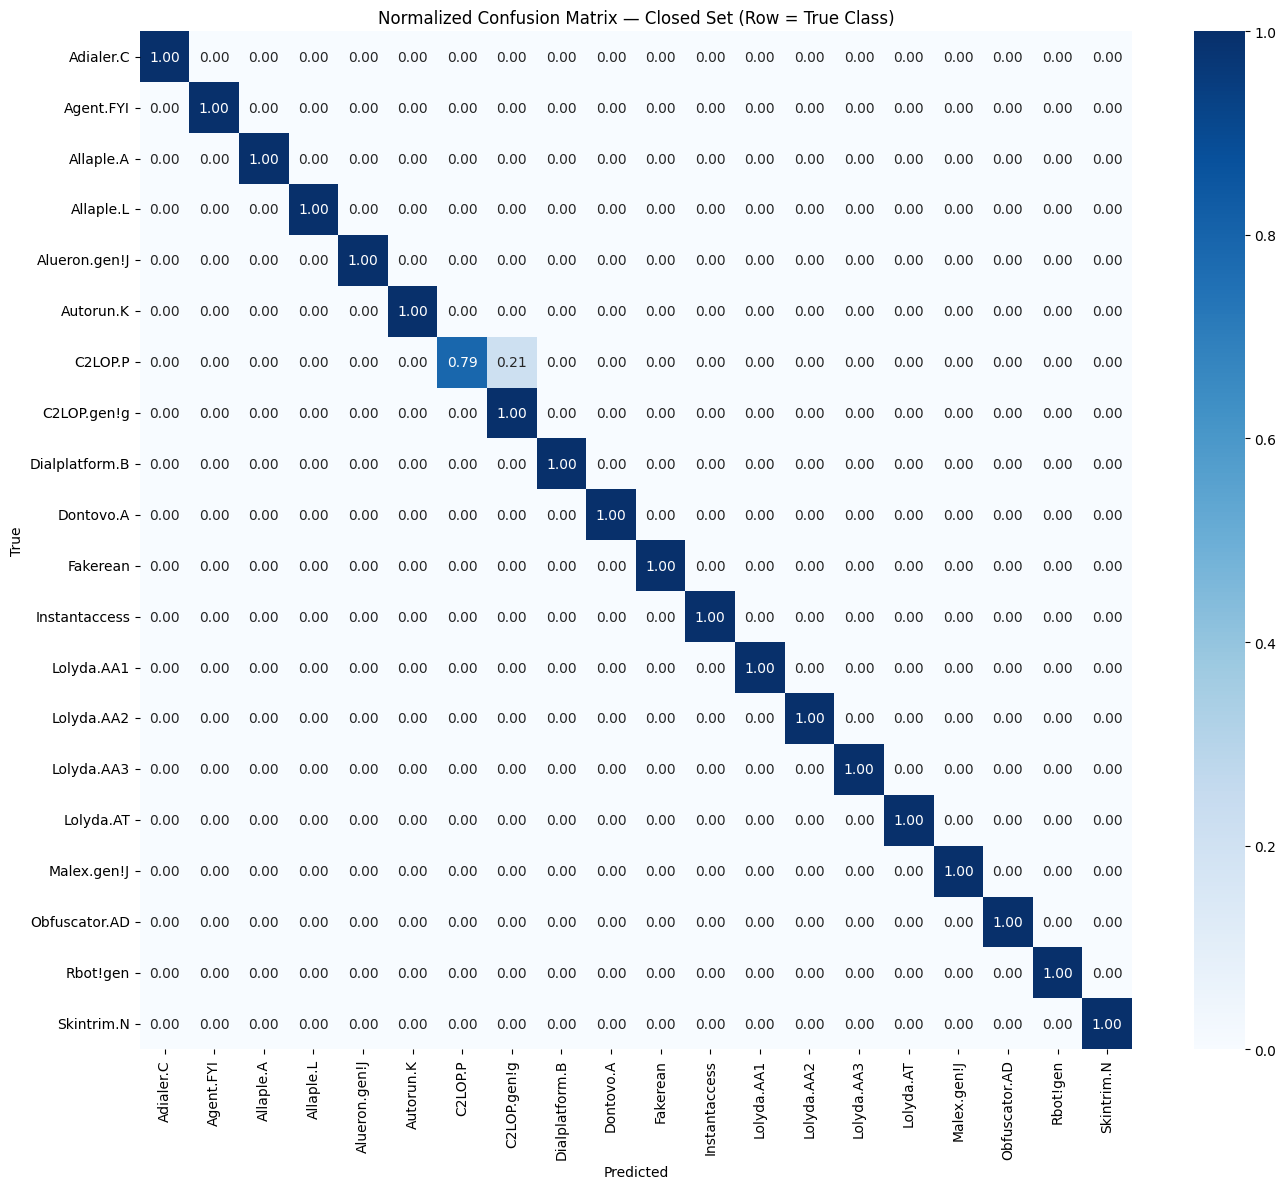

In [2]:
# ===============================
# NORMALIZED CONFUSION MATRIX
# ===============================

# Normalize by true labels (row-wise) — shows recall per class
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    vmin=0,
    vmax=1
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix — Closed Set (Row = True Class)")
plt.tight_layout()
plt.show()